In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_csv('api_data_aadhar_demographic_0_500000.csv')
df2 = pd.read_csv('api_data_aadhar_demographic_500000_1000000.csv')
df3 = pd.read_csv('api_data_aadhar_demographic_1000000_1500000.csv')
df4 = pd.read_csv('api_data_aadhar_demographic_1500000_2000000.csv')
df5 = pd.read_csv('api_data_aadhar_demographic_2000000_2071700.csv')

In [5]:
df1.shape,df2.shape,df3.shape,df4.shape,df5.shape

((500000, 6), (500000, 6), (500000, 6), (500000, 6), (71700, 6))

In [8]:
df = pd.concat([df1,df2,df3,df4,df5],ignore_index=True)

In [9]:
df

,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,01-03-2025,Uttar Pradesh,Gorakhpur,273213,49,529
1,01-03-2025,Andhra Pradesh,Chittoor,517132,22,375
2,01-03-2025,Gujarat,Rajkot,360006,65,765
3,01-03-2025,Andhra Pradesh,Srikakulam,532484,24,314
4,01-03-2025,Rajasthan,Udaipur,313801,45,785
...,...,...,...,...,...,...
2071695,29-12-2025,West Bengal,West Midnapore,721212,0,12
2071696,29-12-2025,West Bengal,West Midnapore,721420,0,1
2071697,29-12-2025,West Bengal,West Midnapore,721424,0,5
2071698,29-12-2025,West Bengal,West Midnapore,721426,0,3


### `Convert` in `Date-year` format

In [12]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

In [13]:
df.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,2025-03-01,Uttar Pradesh,Gorakhpur,273213,49,529
1,2025-03-01,Andhra Pradesh,Chittoor,517132,22,375
2,2025-03-01,Gujarat,Rajkot,360006,65,765
3,2025-03-01,Andhra Pradesh,Srikakulam,532484,24,314
4,2025-03-01,Rajasthan,Udaipur,313801,45,785


In [16]:
df.set_index('date',inplace=True)

In [18]:
df['day_name'] = df.index.day_name()

In [19]:
df['month_name'] = df.index.month_name()

In [20]:
df.head()

,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
date,,,,,,,
2025-03-01,Uttar Pradesh,Gorakhpur,273213,49,529,Saturday,March
2025-03-01,Andhra Pradesh,Chittoor,517132,22,375,Saturday,March
2025-03-01,Gujarat,Rajkot,360006,65,765,Saturday,March
2025-03-01,Andhra Pradesh,Srikakulam,532484,24,314,Saturday,March
2025-03-01,Rajasthan,Udaipur,313801,45,785,Saturday,March


In [24]:
df['state'].unique()

array(['Uttar Pradesh', 'Andhra Pradesh', 'Gujarat', 'Rajasthan',
       'Karnataka', 'West Bengal', 'Telangana', 'Odisha', 'Maharashtra',
       'Kerala', 'Bihar', 'Tamil Nadu', 'Madhya Pradesh', 'Assam',
       'Tripura', 'Arunachal Pradesh', 'Punjab', 'Jharkhand', 'Delhi',
       'Chandigarh', 'Chhattisgarh', 'Jammu and Kashmir', 'Mizoram',
       'Nagaland', 'Himachal Pradesh', 'Goa', 'Haryana', 'Meghalaya',
       'Uttarakhand', 'Manipur', 'Daman and Diu', 'Puducherry', 'Sikkim',
       'Ladakh', 'Dadra and Nagar Haveli and Daman and Diu',
       'Dadra and Nagar Haveli', 'Orissa', 'Pondicherry',
       'Andaman & Nicobar Islands', 'Andaman and Nicobar Islands',
       'west Bengal', 'Daman & Diu', 'West  Bengal', 'odisha',
       'Jammu & Kashmir', 'Lakshadweep', 'Dadra & Nagar Haveli',
       'Westbengal', 'andhra pradesh', 'WEST BENGAL', 'West Bangal',
       'West bengal', 'ODISHA', 'WESTBENGAL', 'Chhatisgarh',
       'West Bengli', 'Darbhanga', 'Puttenahalli', 'BALANAGAR',
  

### `Convert` all `['West Bengal', 'West  Bengal', 'Westbengal', 'WEST BENGAL','West Bangal', 'West bengal', 'WESTBENGAL', 'West Bengli', 'west Bengal']` to `West Bengal`

In [27]:
df[df['state'].str.startswith('w')]['state']

date
2025-09-01    west Bengal
2025-10-24    west Bengal
2025-09-02    west Bengal
2025-10-13    west Bengal
2025-11-16    west Bengal
2025-12-15    west Bengal
2025-09-02    west Bengal
2025-09-16    west Bengal
2025-11-11    west Bengal
2025-11-16    west Bengal
2025-12-15    west Bengal
Name: state, dtype: object

In [29]:
df[df['state'].str.startswith('W')]['state'].unique()

array(['West Bengal', 'West  Bengal', 'Westbengal', 'WEST BENGAL',
       'West Bangal', 'West bengal', 'WESTBENGAL', 'West Bengli'],
      dtype=object)

In [31]:
state_map = {
    'west bengal': 'West Bengal',
    'westbengal': 'West Bengal',
    'west bengli': 'West Bengal'
}

In [32]:
df['state'] = (
    df['state']
    .str.strip()
    .str.lower()
    .replace(state_map)
)

In [33]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'West Bengal', 'telangana', 'odisha', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'dadra and nagar haveli and daman and diu',
       'dadra and nagar haveli', 'orissa', 'pondicherry',
       'andaman & nicobar islands', 'andaman and nicobar islands',
       'daman & diu', 'west  bengal', 'jammu & kashmir', 'lakshadweep',
       'dadra & nagar haveli', 'west bangal', 'chhatisgarh', 'darbhanga',
       'puttenahalli', 'balanagar', 'uttaranchal', '100000', 'jaipur',
       'madanapalle', 'nagpur', 'raja annamalai puram'], dtype=object)

In [34]:
df['state'] = df['state'].str.replace('west  bengal','West Bengal')

In [36]:
df['state'] = df['state'].str.replace('west bangal','West Bengal')

In [37]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'West Bengal', 'telangana', 'odisha', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'dadra and nagar haveli and daman and diu',
       'dadra and nagar haveli', 'orissa', 'pondicherry',
       'andaman & nicobar islands', 'andaman and nicobar islands',
       'daman & diu', 'jammu & kashmir', 'lakshadweep',
       'dadra & nagar haveli', 'chhatisgarh', 'darbhanga', 'puttenahalli',
       'balanagar', 'uttaranchal', '100000', 'jaipur', 'madanapalle',
       'nagpur', 'raja annamalai puram'], dtype=object)

In [38]:
df[df['state'].str.startswith('o')]['state'].unique()

array(['odisha', 'orissa'], dtype=object)

### convert `odisha` to `orissa`

In [40]:
df['state'] = df['state'].str.replace('odisha','orissa')

In [41]:
df[df['state'].str.startswith('o')]['state'].unique()

array(['orissa'], dtype=object)

In [39]:
df[df['state'].str.startswith('a')]['state'].unique()

array(['andhra pradesh', 'assam', 'arunachal pradesh',
       'andaman & nicobar islands', 'andaman and nicobar islands'],
      dtype=object)

### convert `andaman & nicobar islands` to `andaman and nicobar islands`

In [42]:
df['state'] = df['state'].str.replace('andaman & nicobar islands','andaman and nicobar islands')

In [43]:
df[df['state'].str.startswith('a')]['state'].unique()

array(['andhra pradesh', 'assam', 'arunachal pradesh',
       'andaman and nicobar islands'], dtype=object)

In [46]:
df[df['state'].str.startswith('j')]['state'].unique()

array(['jharkhand', 'jammu and kashmir', 'jammu & kashmir', 'jaipur'],
      dtype=object)

### convert `jammu & kashmir` to `jammu and kashmir`

In [47]:
df['state'] = df['state'].str.replace('jammu & kashmir','jammu and kashmir')

In [48]:
df[df['state'].str.startswith('j')]['state'].unique()

array(['jharkhand', 'jammu and kashmir', 'jaipur'], dtype=object)

In [49]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'West Bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'dadra and nagar haveli and daman and diu',
       'dadra and nagar haveli', 'pondicherry',
       'andaman and nicobar islands', 'daman & diu', 'lakshadweep',
       'dadra & nagar haveli', 'chhatisgarh', 'darbhanga', 'puttenahalli',
       'balanagar', 'uttaranchal', '100000', 'jaipur', 'madanapalle',
       'nagpur', 'raja annamalai puram'], dtype=object)

In [50]:
df[df['state'].str.startswith('c')]['state'].unique()

array(['chandigarh', 'chhattisgarh', 'chhatisgarh'], dtype=object)

### convert `chhatisgarh` to `chhattisgarh`

In [51]:
df['state'] = df['state'].str.replace('chhatisgarh','chhattisgarh')

In [52]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'West Bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'dadra and nagar haveli and daman and diu',
       'dadra and nagar haveli', 'pondicherry',
       'andaman and nicobar islands', 'daman & diu', 'lakshadweep',
       'dadra & nagar haveli', 'darbhanga', 'puttenahalli', 'balanagar',
       'uttaranchal', '100000', 'jaipur', 'madanapalle', 'nagpur',
       'raja annamalai puram'], dtype=object)

In [53]:
df[df['state'].str.startswith('d')]['state'].unique()

array(['delhi', 'daman and diu',
       'dadra and nagar haveli and daman and diu',
       'dadra and nagar haveli', 'daman & diu', 'dadra & nagar haveli',
       'darbhanga'], dtype=object)

In [55]:
df.to_csv('concated.csv')

In [2]:
df = pd.read_csv('concated.csv')

In [3]:
df.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
0,2025-03-01,uttar pradesh,Gorakhpur,273213,49,529,Saturday,March
1,2025-03-01,andhra pradesh,Chittoor,517132,22,375,Saturday,March
2,2025-03-01,gujarat,Rajkot,360006,65,765,Saturday,March
3,2025-03-01,andhra pradesh,Srikakulam,532484,24,314,Saturday,March
4,2025-03-01,rajasthan,Udaipur,313801,45,785,Saturday,March


In [4]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'West Bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'dadra and nagar haveli and daman and diu',
       'dadra and nagar haveli', 'pondicherry',
       'andaman and nicobar islands', 'daman & diu', 'lakshadweep',
       'dadra & nagar haveli', 'darbhanga', 'puttenahalli', 'balanagar',
       'uttaranchal', '100000', 'jaipur', 'madanapalle', 'nagpur',
       'raja annamalai puram'], dtype=object)

In [5]:
df[df['state'].str.startswith('d')]['state'].unique()

array(['delhi', 'daman and diu',
       'dadra and nagar haveli and daman and diu',
       'dadra and nagar haveli', 'daman & diu', 'dadra & nagar haveli',
       'darbhanga'], dtype=object)

### `Convert` all `['dadra and nagar haveli and daman and diu','dadra and nagar haveli', 'daman & diu', 'dadra & nagar haveli']` to `daman and diu`

In [6]:
state_map = {
    'dadra and nagar haveli and daman and diu': 'daman and diu',
    'dadra and nagar haveli': 'daman and diu',
    'daman & diu': 'daman and diu',
    'dadra & nagar haveli':'daman and diu'
}

In [7]:
df['state'] = (
    df['state']
    .str.strip()
    .str.lower()
    .str.replace('&', 'and', regex=False)
    .str.replace(r'\s+', ' ', regex=True)
)

In [8]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'dadra and nagar haveli and daman and diu',
       'dadra and nagar haveli', 'pondicherry',
       'andaman and nicobar islands', 'lakshadweep', 'darbhanga',
       'puttenahalli', 'balanagar', 'uttaranchal', '100000', 'jaipur',
       'madanapalle', 'nagpur', 'raja annamalai puram'], dtype=object)

In [9]:
df[df['state'].str.startswith('d')]['state'].unique()

array(['delhi', 'daman and diu',
       'dadra and nagar haveli and daman and diu',
       'dadra and nagar haveli', 'darbhanga'], dtype=object)

In [10]:
state_map = {
    'dadra and nagar haveli and daman and diu': 'daman and diu',
    'dadra and nagar haveli': 'daman and diu'
}

In [11]:
df['state'] = df['state'].replace(state_map)

In [17]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'pondicherry', 'andaman and nicobar islands',
       'lakshadweep', 'darbhanga', 'puttenahalli', 'balanagar',
       'uttaranchal', '100000', 'jaipur', 'madanapalle', 'nagpur',
       'raja annamalai puram'], dtype=object)

In [13]:
df[df['state'].str.startswith('m')]['state'].unique()

array(['maharashtra', 'madhya pradesh', 'mizoram', 'meghalaya', 'manipur',
       'madanapalle'], dtype=object)

In [18]:
df['state'].value_counts()

state
andhra pradesh                 207740
tamil nadu                     196857
west bengal                    169070
uttar pradesh                  167889
maharashtra                    162242
karnataka                      153957
orissa                         105935
kerala                         105515
bihar                           97621
gujarat                         96399
rajasthan                       89508
telangana                       89086
madhya pradesh                  76364
assam                           62834
punjab                          49611
jharkhand                       39653
chhattisgarh                    35730
haryana                         28554
himachal pradesh                28037
uttarakhand                     23065
jammu and kashmir               20601
delhi                           10510
tripura                          8845
manipur                          7289
goa                              5921
meghalaya                        5363
arunac

### convert `pondicherry` to `puducherry`

In [19]:
df['state'] = df['state'].str.replace('pondicherry','puducherry')

In [22]:
df[df['state'] == '100000']

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
795161,2025-12-23,100000,100000,100000,0,1,Tuesday,December
2007370,2025-12-20,100000,100000,100000,0,1,Saturday,December


| City                 | Correct State   |
|----------------------|-----------------|
| Madanapalle          | Andhra Pradesh  |
| Jaipur               | Rajasthan       |
| Darbhanga            | Bihar           |
| Balanagar            | Telangana       |
| Puttenahalli         | Karnataka       |
| Nagpur               | Maharashtra     |
| Raja Annamalai Puram | Tamil Nadu      |

In [27]:
name_map = {
    'madanapalle': 'andhra pradesh',
    'jaipur': 'rajasthan',
    'darbhanga': 'bihar',
    'balanagar': 'telangana',
    'puttenahalli': 'karnataka',
    'nagpur': 'maharashtra',
    'raja annamalai puram': 'tamil nadu',
    '100000': 'unknown'
}

In [28]:
df['state'] = df['state'].replace(name_map)


<Axes: ylabel='count'>

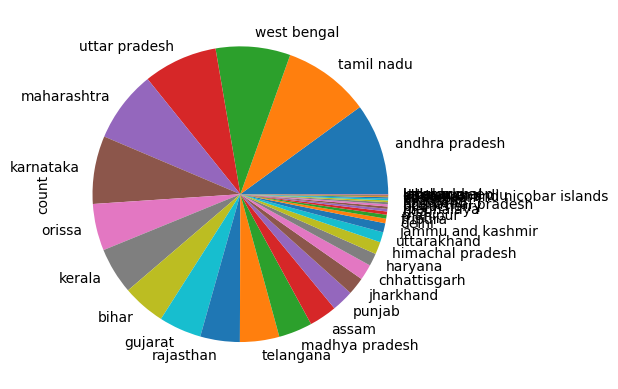

In [30]:
df['state'].value_counts().plot(kind='pie')

In [32]:
df.to_csv('fixed_state.csv',index=False)

In [33]:
df.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
0,2025-03-01,uttar pradesh,Gorakhpur,273213,49,529,Saturday,March
1,2025-03-01,andhra pradesh,Chittoor,517132,22,375,Saturday,March
2,2025-03-01,gujarat,Rajkot,360006,65,765,Saturday,March
3,2025-03-01,andhra pradesh,Srikakulam,532484,24,314,Saturday,March
4,2025-03-01,rajasthan,Udaipur,313801,45,785,Saturday,March


In [34]:
df['district'].unique()

array(['Gorakhpur', 'Chittoor', 'Rajkot', 'Srikakulam', 'Udaipur',
       'Sikar', 'Tumakuru', 'Kurnool', 'Paschim Medinipur', 'Ghazipur',
       'Patan', 'Mulugu', 'Ganganagar', 'Nayagarh', 'Nashik',
       'Shivamogga', 'Thrissur', 'Hassan', 'Patna', 'Belgaum',
       'Kancheepuram', 'Jabalpur', 'Chennai', 'Tinsukia', 'Jamui', 'Gaya',
       'Bengaluru', 'Tiruppur', 'Jalgaon', 'Dhalai', 'Nabarangapur',
       'Chittorgarh', 'Darbhanga', 'Purnia', 'Muzaffarnagar', 'Jaipur',
       'Churu', 'Bharatpur', 'Jamnagar', 'Howrah', 'Ahmedabad',
       'West Kameng', 'Jalor', 'Belagavi', 'Bahraich', 'Nagapattinam',
       'Sheikhpura', 'Amritsar', 'Mysore', 'Alluri Sitharama Raju',
       'Sitamarhi', 'Khunti', 'Saharanpur', 'Kanyakumari', 'Prakasam',
       'Ananthapuramu', 'Hooghly', 'Central Delhi', 'Deoria', 'Giridih',
       'Koraput', 'Shahjahanpur', 'Chhotaudepur', 'Jalandhar', 'Kannauj',
       'Visakhapatnam', 'Jodhpur', 'Karimnagar', 'Amethi', 'Hyderabad',
       'Salem', 'Cuddalore'

In [35]:
df['district'] = (
    df['district']
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

In [36]:
state_gr = df.groupby('state')

In [38]:
state_gr['district'].value_counts()

state                        district                
andaman and nicobar islands  south andaman               940
                             north and middle andaman    338
                             andamans                    314
                             nicobar                     128
                             nicobars                      4
                                                        ... 
west bengal                  west medinipur               10
                             south dumdum(m)               6
                             domjur                        2
                             naihati anandabazar           2
                             bally jagachha                1
Name: count, Length: 981, dtype: int64

In [39]:
import re

def basic_clean(text):
    if pd.isna(text):
        return 'unknown'
    
    text = str(text).lower()
    text = text.strip()
    text = text.replace('&', 'and')
    text = re.sub(r'\s+', ' ', text)          # fix multiple spaces
    text = re.sub(r'[^\w\s]', '', text)       # remove symbols *, (), etc.
    
    return text


In [40]:
df['district'] = df['district'].apply(basic_clean)

### `Known renames (historical → current)`

In [41]:
rename_map = {
    'allahabad': 'prayagraj',
    'faizabad': 'ayodhya',
    'aurangabad': 'chhatrapati sambhajinagar',
    'gulbarga': 'kalaburagi',
    'bellary': 'ballari',
    'cuddapah': 'ysr kadapa',
    'rangareddi': 'rangareddy',
    'ahmadabad': 'ahmedabad'
}

In [42]:
df['district'] = df['district'].replace(rename_map)

### `Spelling & phonetic variants`

In [43]:
spelling_map = {
    'hooghiy': 'hooghly',
    'hugli': 'hooghly',
    'haora': 'howrah',
    'barddhaman': 'bardhaman',
    'medinipur': 'midnapore',
    'purnea': 'purnia',
    'buldana': 'buldhana',
    'bid': 'beed',
    'gondiya': 'gondia'
}

In [44]:
df['district'] = df['district'].replace(spelling_map)

### `Normalize number-based districts`

In [45]:
number_map = {
    'south twenty four parganas': 'south 24 parganas',
    'north twenty four parganas': 'north 24 parganas',
    'south 24 pargana': 'south 24 parganas',
    'north 24 pargana': 'north 24 parganas'
}

In [46]:
df['district'] = df['district'].replace(number_map)

### `Remove address / locality garbage`

In [47]:
garbage_pattern = (
    r'near|colony|road|cross|thana|hospital|dist|university|'
    r'5th|sector|block|garden|market'
)

In [48]:
df.loc[df['district'].str.contains(garbage_pattern, regex=True), 'district'] = 'unknown' 

In [49]:
valid_districts = set(df['district'].value_counts().index)

In [50]:
df.loc[~df['district'].isin(valid_districts), 'district'].value_counts().head(30)

Series([], Name: count, dtype: int64)

In [51]:
valid_districts

{'100000',
 'adilabad',
 'agar malwa',
 'agra',
 'ahilyanagar',
 'ahmadnagar',
 'ahmed nagar',
 'ahmedabad',
 'aizawl',
 'ajmer',
 'akola',
 'alappuzha',
 'aligarh',
 'alipurduar',
 'alirajpur',
 'alluri sitharama raju',
 'almora',
 'alwar',
 'ambala',
 'ambedkar nagar',
 'amethi',
 'amravati',
 'amreli',
 'amritsar',
 'amroha',
 'anakapalli',
 'anand',
 'anantapur',
 'ananthapur',
 'ananthapuramu',
 'anantnag',
 'andamans',
 'angul',
 'anjaw',
 'annamayya',
 'anugal',
 'anugul',
 'anuppur',
 'araria',
 'ariyalur',
 'arvalli',
 'arwal',
 'ashok nagar',
 'auraiya',
 'aurangabadbh',
 'ayodhya',
 'azamgarh',
 'badgam',
 'bagalkot',
 'bagalkot ',
 'bageshwar',
 'baghpat',
 'baghpat ',
 'bagpat',
 'bahraich',
 'bajali',
 'baksa',
 'balaghat',
 'balangir',
 'baleshwar',
 'baleswar',
 'balianta',
 'ballari',
 'ballia',
 'bally jagachha',
 'balod',
 'baloda bazar',
 'balotra',
 'balrampur',
 'banas kantha',
 'banaskantha',
 'banda',
 'bandipore',
 'bandipur',
 'bangalore',
 'bangalore rural',


In [52]:
df.to_csv('upto_the_mark.csv',index=False)

In [53]:
df.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
0,2025-03-01,uttar pradesh,gorakhpur,273213,49,529,Saturday,March
1,2025-03-01,andhra pradesh,chittoor,517132,22,375,Saturday,March
2,2025-03-01,gujarat,rajkot,360006,65,765,Saturday,March
3,2025-03-01,andhra pradesh,srikakulam,532484,24,314,Saturday,March
4,2025-03-01,rajasthan,udaipur,313801,45,785,Saturday,March


In [56]:
len(df['state'].unique())

38

In [57]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `Uttar-Pradesh`

In [59]:
df_uttar = df[df['state'] == 'uttar pradesh']

In [60]:
df_uttar.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
0,2025-03-01,uttar pradesh,gorakhpur,273213,49,529,Saturday,March
7,2025-03-01,uttar pradesh,gorakhpur,273211,61,836,Saturday,March
10,2025-03-01,uttar pradesh,ghazipur,233226,134,1591,Saturday,March
35,2025-03-01,uttar pradesh,muzaffarnagar,247775,22,222,Saturday,March
45,2025-03-01,uttar pradesh,bahraich,271821,54,556,Saturday,March


In [61]:
df_uttar['district'].value_counts()

district
prayagraj               6728
ayodhya                 5735
lucknow                 4373
jaunpur                 4281
azamgarh                4156
                        ... 
bagpat                    10
baghpat                    3
jyotiba phule nagar        1
chitrakoot                 1
chandauli                  1
Name: count, Length: 88, dtype: int64

In [62]:
df_uttar['district'].unique()

array(['gorakhpur', 'ghazipur', 'muzaffarnagar', 'bahraich', 'saharanpur',
       'deoria', 'shahjahanpur', 'kannauj', 'amethi', 'siddharthnagar',
       'bara banki', 'hardoi', 'ambedkar nagar', 'auraiya', 'prayagraj',
       'pratapgarh', 'balrampur', 'rae bareli', 'azamgarh', 'amroha',
       'sultanpur', 'gonda', 'mainpuri', 'moradabad', 'varanasi',
       'bijnor', 'firozabad', 'farrukhabad', 'basti', 'jaunpur',
       'maharajganj', 'kaushambi', 'sitapur', 'aligarh', 'kheri', 'mau',
       'sonbhadra', 'bulandshahr', 'fatehpur', 'ayodhya', 'kasganj',
       'ballia', 'kanpur nagar', 'lucknow', 'agra', 'sant kabir nagar',
       'shrawasti', 'bhadohi', 'ghaziabad', 'lalitpur', 'meerut',
       'mathura', 'etah', 'etawah', 'gautam buddha nagar', 'hathras',
       'rampur', 'bareilly', 'jhansi', 'pilibhit', 'hamirpur', 'shamli',
       'mahoba', 'sambhal', 'sant ravidas nagar', 'kanpur dehat',
       'baghpat', 'kushinagar', 'mirzapur', 'budaun', 'unnao', 'jalaun',
       'hapur', '

| Variations found                                        | Standard name                              |
|--------------------------------------------------------|--------------------------------------------|
| bara banki, barabanki                                   | **barabanki**                              |
| rae bareli, raebareli                                   | **rae bareli**                             |
| bulandshahar, bulandshahr                               | **bulandshahr**                            |
| kushinagar, kushinagar                                  | **kushinagar**                             |
| mahrajganj, maharajganj                                 | **maharajganj**                            |
| bagpat, baghpat                                         | **baghpat**                                |
| sant ravidas nagar, bhadohi, sant ravidas nagar bhadohi | **bhadohi**                                |
| jyotiba phule nagar                                     | **amroha** (official renamed)              |
| kheri                                                   | **lakhimpur kheri**                        |
| prayagraj                                               | **prayagraj** (earlier Allahabad)          |
| ayodhya                                                 | **ayodhya** (earlier Faizabad)             |


In [70]:
uttar_mapping = {
    "bara banki": "barabanki",
    "barabanki": "barabanki",

    "rae bareli": "rae bareli",
    "raebareli": "rae bareli",

    "bulandshahar": "bulandshahr",
    "bulandshahr": "bulandshahr",

    "kushinagar": "kushinagar",
    "kushinagar ": "kushinagar",

    "mahrajganj": "maharajganj",
    "maharajganj": "maharajganj",

    "bagpat": "baghpat",
    "baghpat": "baghpat",
    "baghpat ": "baghpat",

    "sant ravidas nagar": "bhadohi",
    "sant ravidas nagar bhadohi": "bhadohi",
    "bhadohi": "bhadohi",

    "jyotiba phule nagar": "amroha",
    "jyotiba phule nagar ": "amroha",

    "kheri": "lakhimpur kheri",

    "chitrakoot ": "chitrakoot",
    "chandauli ": "chandauli"
}

In [65]:
df_uttar['district'] = (
    df_uttar['district']
    .str.lower()
    .str.strip()
    .replace(district_mapping)
)

C:\Users\dell g3\AppData\Local\Temp\ipykernel_5204\1361998901.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_uttar['district'] = (


In [68]:
df_uttar['district'].unique()

array(['gorakhpur', 'ghazipur', 'muzaffarnagar', 'bahraich', 'saharanpur',
       'deoria', 'shahjahanpur', 'kannauj', 'amethi', 'siddharthnagar',
       'barabanki', 'hardoi', 'ambedkar nagar', 'auraiya', 'prayagraj',
       'pratapgarh', 'balrampur', 'rae bareli', 'azamgarh', 'amroha',
       'sultanpur', 'gonda', 'mainpuri', 'moradabad', 'varanasi',
       'bijnor', 'firozabad', 'farrukhabad', 'basti', 'jaunpur',
       'maharajganj', 'kaushambi', 'sitapur', 'aligarh',
       'lakhimpur kheri', 'mau', 'sonbhadra', 'bulandshahr', 'fatehpur',
       'ayodhya', 'kasganj', 'ballia', 'kanpur nagar', 'lucknow', 'agra',
       'sant kabir nagar', 'shrawasti', 'bhadohi', 'ghaziabad',
       'lalitpur', 'meerut', 'mathura', 'etah', 'etawah',
       'gautam buddha nagar', 'hathras', 'rampur', 'bareilly', 'jhansi',
       'pilibhit', 'hamirpur', 'shamli', 'mahoba', 'sambhal',
       'kanpur dehat', 'baghpat', 'kushinagar', 'mirzapur', 'budaun',
       'unnao', 'jalaun', 'hapur', 'chandauli', '

In [69]:
df[df['state'] == 'uttar pradesh']

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
0,2025-03-01,uttar pradesh,gorakhpur,273213,49,529,Saturday,March
7,2025-03-01,uttar pradesh,gorakhpur,273211,61,836,Saturday,March
10,2025-03-01,uttar pradesh,ghazipur,233226,134,1591,Saturday,March
35,2025-03-01,uttar pradesh,muzaffarnagar,247775,22,222,Saturday,March
45,2025-03-01,uttar pradesh,bahraich,271821,54,556,Saturday,March
...,...,...,...,...,...,...,...,...
2071242,2025-12-29,uttar pradesh,varanasi,221204,3,27,Monday,December
2071243,2025-12-29,uttar pradesh,varanasi,221207,2,14,Monday,December
2071244,2025-12-29,uttar pradesh,varanasi,221208,2,17,Monday,December
2071245,2025-12-29,uttar pradesh,varanasi,221302,1,20,Monday,December


In [74]:
mask = df['state'].str.lower().str.strip() == 'uttar pradesh'

df.loc[mask, 'district'] = (
    df.loc[mask, 'district']
      .str.lower()
      .str.strip()
      .replace(uttar_mapping)
)

In [79]:
len(list(df[df['state'] == 'uttar pradesh']['district'].value_counts()))

75

In [82]:
df_uttar.to_csv('uttar_pradesh.csv')

In [81]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `andhra pradesh`

In [132]:
df_andhra =  df[df['state'] == 'andhra pradesh']

In [133]:
df_andhra.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
1,2025-03-01,andhra pradesh,chittoor,517132,22,375,Saturday,March
3,2025-03-01,andhra pradesh,srikakulam,532484,24,314,Saturday,March
8,2025-03-01,andhra pradesh,kurnool,518313,83,986,Saturday,March
48,2025-03-01,andhra pradesh,chittoor,517291,10,145,Saturday,March
52,2025-03-01,andhra pradesh,alluri sitharama raju,531040,14,454,Saturday,March


In [134]:
df_andhra['district'].value_counts()

district
ananthapuramu                  19696
east godavari                  12186
sri potti sriramulu nellore    10738
ysr kadapa                     10032
west godavari                  10007
krishna                         9123
guntur                          9101
prakasam                        8873
chittoor                        8514
visakhapatnam                   7984
kurnool                         7445
srikakulam                      6107
vizianagaram                    5747
eluru                           3755
tirupati                        3711
konaseema                       3581
sri sathya sai                  3519
annamayya                       3195
ntr                             3076
nandyal                         2966
palnadu                         2931
bapatla                         2925
kakinada                        2875
anakapalli                      2662
alluri sitharama raju           2176
parvathipuram manyam            1833
unknown                      

In [135]:
df_andhra['district'].unique()

array(['chittoor', 'srikakulam', 'kurnool', 'alluri sitharama raju',
       'prakasam', 'ananthapuramu', 'visakhapatnam', 'east godavari',
       'annamayya', 'anakapalli', 'krishna', 'parvathipuram manyam',
       'west godavari', 'nandyal', 'ysr kadapa', 'vizianagaram',
       'kakinada', 'palnadu', 'ntr', 'eluru', 'konaseema', 'guntur',
       'bapatla', 'sri sathya sai', 'sri potti sriramulu nellore',
       'tirupati', 'unknown'], dtype=object)

In [112]:
andhra_mapping = {
    "ananthapur": "ananthapuramu",
    "anantapur": "ananthapuramu",
    "ananthapuramu": "ananthapuramu",

    "y s r": "ysr kadapa",
    "ysr kadapa": "ysr kadapa",

    "nellore": "sri potti sriramulu nellore",
    "sri potti sriramulu nellore": "sri potti sriramulu nellore",

    "n t r": "ntr",

    "dr b r ambedkar konaseema": "konaseema",

    "unknown": "unknown"
}

In [113]:
mask_ap = df['state'].str.lower().str.strip() == 'andhra pradesh'

df.loc[mask_ap, 'district'] = (
    df.loc[mask_ap, 'district']
      .str.lower()
      .str.strip()
      .replace(andhra_mapping)
)

In [117]:
len(df[df['state'] == 'andhra pradesh']['district'].unique())

32

In [118]:
df[df['state'] == 'andhra pradesh']['district'].unique()

array(['chittoor', 'srikakulam', 'kurnool', 'alluri sitharama raju',
       'prakasam', 'ananthapuramu', 'visakhapatnam', 'east godavari',
       'annamayya', 'anakapalli', 'krishna', 'parvathipuram manyam',
       'west godavari', 'nandyal', 'ysr kadapa', 'vizianagaram',
       'kakinada', 'palnadu', 'ntr', 'eluru', 'konaseema', 'guntur',
       'bapatla', 'sri sathya sai', 'sri potti sriramulu nellore',
       'tirupati', 'kvrangareddy', 'karim nagar', 'mahabub nagar',
       'mahabubnagar', 'kv rangareddy', 'unknown'], dtype=object)

In [136]:
df_andhra.to_csv('andhra_pradesh.csv')

<Axes: ylabel='count'>

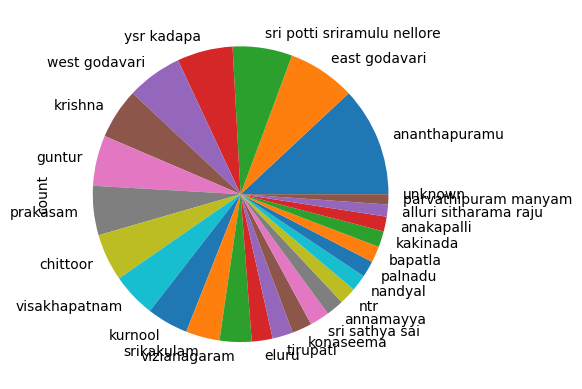

In [138]:
df[df['state'] == 'andhra pradesh']['district'].value_counts().plot(kind='pie')

### Many listed district of andhra pradesh like `rangareddy, karim nagar, mahabub nagar, mahabubnagar` and `"hyderabad","rangareddy","warangal","khammam","adilabad", "mahbubnagar", "karimnagar","medak", "nalgonda", "nizamabad"` these district are from `Telengana`  

In [119]:
rangareddy_variants = [
    "kvrangareddy",
    "kv rangareddy",
    "rangareddy"
]

In [121]:
df.loc[df['district'].isin(rangareddy_variants), 'district'] = "rangareddy"

In [131]:
df[df['state'] == 'andhra pradesh']['district'].unique()

array(['chittoor', 'srikakulam', 'kurnool', 'alluri sitharama raju',
       'prakasam', 'ananthapuramu', 'visakhapatnam', 'east godavari',
       'annamayya', 'anakapalli', 'krishna', 'parvathipuram manyam',
       'west godavari', 'nandyal', 'ysr kadapa', 'vizianagaram',
       'kakinada', 'palnadu', 'ntr', 'eluru', 'konaseema', 'guntur',
       'bapatla', 'sri sathya sai', 'sri potti sriramulu nellore',
       'tirupati', 'unknown'], dtype=object)

In [125]:
df['district'] = df['district'].replace({
    "karim nagar": "karimnagar",
    "mahabub nagar": "mahbubnagar"
})

In [104]:
telangana_districts = [
    "hyderabad", "rangareddy", "warangal", "khammam",
    "adilabad", "mahbubnagar", "karimnagar",
    "medak", "nalgonda", "nizamabad"
]

In [105]:
mask_telangana = (
    df['district'].isin(telangana_districts)
)

In [107]:
df.loc[mask_telangana, 'state'] = 'telangana'

In [130]:
telangana_districts_2 = [
    "mahabubnagar"
]

df.loc[df['district'].isin(telangana_districts_2), 'state'] = "telangana"


In [139]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

In [140]:
df.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
0,2025-03-01,uttar pradesh,gorakhpur,273213,49,529,Saturday,March
1,2025-03-01,andhra pradesh,chittoor,517132,22,375,Saturday,March
2,2025-03-01,gujarat,rajkot,360006,65,765,Saturday,March
3,2025-03-01,andhra pradesh,srikakulam,532484,24,314,Saturday,March
4,2025-03-01,rajasthan,udaipur,313801,45,785,Saturday,March


### `Gujrat`

In [154]:
df_gujrat = df[df['state'] == 'gujarat']

In [155]:
df_gujrat['district'].value_counts()

district
ahmedabad          9710
surat              6226
vadodara           6135
anand              4626
kachchh            4155
rajkot             4074
kheda              4056
sabarkantha        3986
junagadh           3861
jamnagar           3626
bhavnagar          3617
mahesana           3600
bharuch            3187
gandhinagar        3177
surendranagar      3117
navsari            2871
amreli             2829
valsad             2711
banaskantha        2600
panchmahals        2554
dahod              2153
patan              1748
tapi               1536
arvalli            1415
gir somnath        1200
mahisagar          1159
porbandar          1157
chhota udaipur     1148
devbhumi dwarka    1092
narmada             991
botad               911
morbi               783
dang                388
Name: count, dtype: int64

In [156]:
df_gujrat['district'].unique()

array(['rajkot', 'patan', 'jamnagar', 'ahmedabad', 'chhota udaipur',
       'sabarkantha', 'porbandar', 'devbhumi dwarka', 'gandhinagar',
       'surendranagar', 'mahesana', 'dahod', 'kheda', 'surat', 'valsad',
       'vadodara', 'arvalli', 'botad', 'morbi', 'kachchh', 'anand',
       'bharuch', 'gir somnath', 'junagadh', 'banaskantha', 'bhavnagar',
       'navsari', 'panchmahals', 'amreli', 'tapi', 'mahisagar', 'dang',
       'narmada'], dtype=object)

| Variations found              | Standard name       |
| ----------------------------- | ------------------- |
| surendra nagar, surendranagar | **surendranagar**   |
| sabarkantha, sabar kantha     | **sabarkantha**     |
| banaskantha, banas kantha     | **banaskantha**     |
| panchmahals, panch mahals     | **panchmahals**     |
| dahod, dohad                  | **dahod**           |
| chhotaudepur                  | **chhota udaipur**  |
| devbhumi dwarka               | **devbhumi dwarka** |
| the dangs                     | **dang**            |
| kachchh                       | **kachchh**         |
| gir somnath                   | **gir somnath**     |


In [147]:
gujarat_mapping = {
    "surendra nagar": "surendranagar",
    "surendranagar": "surendranagar",

    "sabar kantha": "sabarkantha",
    "sabarkantha": "sabarkantha",

    "banas kantha": "banaskantha",
    "banaskantha": "banaskantha",

    "panch mahals": "panchmahals",
    "panchmahals": "panchmahals",

    "dohad": "dahod",
    "dahod": "dahod",

    "chhotaudepur": "chhota udaipur",

    "the dangs": "dang"
}

In [148]:
mask_guj = df['state'].str.lower().str.strip() == 'gujarat'

df.loc[mask_guj, 'district'] = (
    df.loc[mask_guj, 'district']
      .str.lower()
      .str.strip()
      .replace(gujarat_mapping)
)

In [157]:
df_gujrat.to_csv('Gujrat.csv')

<Axes: ylabel='count'>

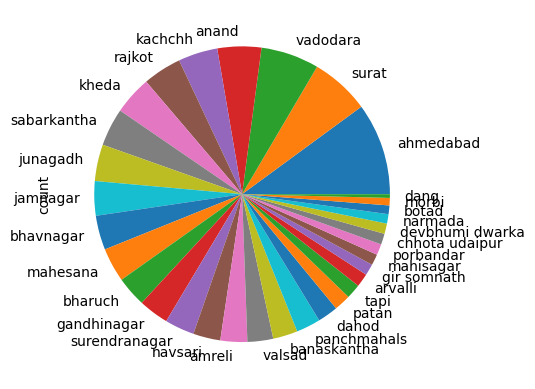

In [153]:
df[df['state'] == 'gujarat']['district'].value_counts().plot(kind='pie')

In [158]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `Rajasthan`

In [166]:
df_raj = df[df['state'] == 'rajasthan']

In [167]:
df_raj.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
4,2025-03-01,rajasthan,udaipur,313801,45,785,Saturday,March
5,2025-03-01,rajasthan,sikar,332028,28,285,Saturday,March
13,2025-03-01,rajasthan,ganganagar,335027,25,545,Saturday,March
32,2025-03-01,rajasthan,chittorgarh,312023,274,2259,Saturday,March
36,2025-03-01,rajasthan,jaipur,303701,54,346,Saturday,March


In [168]:
df_raj['district'].value_counts()

district
jaipur              6761
jhunjhunu           5318
sikar               4616
ajmer               4470
alwar               4172
nagaur              3856
pali                3591
jodhpur             3557
udaipur             3425
chittorgarh         3313
bhilwara            2780
bharatpur           2766
kota                2521
barmer              2379
ganganagar          2352
bikaner             2326
jalor               2308
rajsamand           2216
dausa               2211
dungarpur           2181
sawai madhopur      2167
churu               2112
karauli             2078
banswara            1589
sirohi              1556
jhalawar            1551
hanumangarh         1535
bundi               1421
tonk                1364
dholpur             1267
baran               1204
pratapgarh          1142
jaisalmer           1033
deeg                 623
didwana kuchaman     426
kotputli behror      308
balotra              255
khairthal tijara     242
beawar               215
salumbar        

In [169]:
df_raj['district'].unique()

array(['udaipur', 'sikar', 'ganganagar', 'chittorgarh', 'jaipur', 'churu',
       'bharatpur', 'jalor', 'jodhpur', 'dholpur', 'bikaner', 'alwar',
       'bundi', 'rajsamand', 'jhalawar', 'ajmer', 'pali', 'pratapgarh',
       'dausa', 'nagaur', 'jhunjhunu', 'sirohi', 'bhilwara', 'tonk',
       'hanumangarh', 'banswara', 'kota', 'baran', 'barmer', 'karauli',
       'sawai madhopur', 'jaisalmer', 'dungarpur', 'deeg', 'salumbar',
       'beawar', 'didwana kuchaman', 'kotputli behror', 'phalodi',
       'balotra', 'khairthal tijara', 'unknown'], dtype=object)

| Variations found          | Standard name        |
| ------------------------- | -------------------- |
| chittorgarh, chittaurgarh | **chittorgarh**      |
| dholpur, dhaulpur         | **dholpur**          |
| jhunjhunun, jhunjhunu     | **jhunjhunu**        |
| jalor, jalore             | **jalor**            |
| didwanakuchaman           | **didwana kuchaman** |
| kotputlibehror            | **kotputli behror**  |
| khairthaltijara           | **khairthal tijara** |

In [163]:
rajasthan_mapping = {
    "chittaurgarh": "chittorgarh",
    "chittorgarh": "chittorgarh",

    "dhaulpur": "dholpur",
    "dholpur": "dholpur",

    "jhunjhunun": "jhunjhunu",
    "jhunjhunu": "jhunjhunu",

    "jalore": "jalor",
    "jalor": "jalor",

    "didwanakuchaman": "didwana kuchaman",
    "kotputlibehror": "kotputli behror",
    "khairthaltijara": "khairthal tijara"
}

In [164]:
mask_raj = df['state'].str.lower().str.strip() == 'rajasthan'

df.loc[mask_raj, 'district'] = (
    df.loc[mask_raj, 'district']
      .str.lower()
      .str.strip()
      .replace(rajasthan_mapping)
)

In [165]:
df[df['state'] == 'rajasthan']['district'].unique()

array(['udaipur', 'sikar', 'ganganagar', 'chittorgarh', 'jaipur', 'churu',
       'bharatpur', 'jalor', 'jodhpur', 'dholpur', 'bikaner', 'alwar',
       'bundi', 'rajsamand', 'jhalawar', 'ajmer', 'pali', 'pratapgarh',
       'dausa', 'nagaur', 'jhunjhunu', 'sirohi', 'bhilwara', 'tonk',
       'hanumangarh', 'banswara', 'kota', 'baran', 'barmer', 'karauli',
       'sawai madhopur', 'jaisalmer', 'dungarpur', 'deeg', 'salumbar',
       'beawar', 'didwana kuchaman', 'kotputli behror', 'phalodi',
       'balotra', 'khairthal tijara', 'unknown'], dtype=object)

In [170]:
df_raj.to_csv('rajasthan.csv')

<Axes: ylabel='count'>

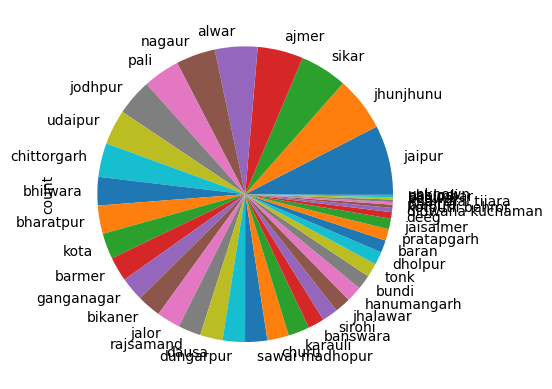

In [172]:
df[df['state'] == 'rajasthan']['district'].value_counts().plot(kind='pie')

In [173]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `karnataka`

In [188]:
df_kar = df[df['state'] == 'karnataka']

In [189]:
df_kar.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
6,2025-03-01,karnataka,tumakuru,572201,88,332,Saturday,March
16,2025-03-01,karnataka,shivamogga,577425,11,30,Saturday,March
18,2025-03-01,karnataka,hassan,573144,23,53,Saturday,March
20,2025-03-01,karnataka,belagavi,591118,27,56,Saturday,March
27,2025-03-01,karnataka,bengaluru urban,560072,92,438,Saturday,March


In [190]:
df_kar['district'].value_counts()

district
bengaluru urban     18992
belagavi            15626
mysuru               8983
tumakuru             8663
dakshina kannada     7338
vijayapura           7075
hassan               6783
shivamogga           6705
kalaburagi           6193
ballari              5796
chikkamagaluru       5335
udupi                5212
uttara kannada       5058
davanagere           4641
bagalkot             3611
mandya               3423
dharwad              3135
chamarajanagar       3051
chitradurga          2953
haveri               2765
yadgir               2754
raichur              2581
kolar                2380
gadag                2254
bidar                2191
koppal               2052
vijayanagara         1903
kodagu               1867
chikkaballapur       1670
ramanagar            1484
bengaluru rural      1483
unknown                 1
Name: count, dtype: int64

In [191]:
df_kar['district'].unique()

array(['tumakuru', 'shivamogga', 'hassan', 'belagavi', 'bengaluru urban',
       'mysuru', 'kolar', 'dakshina kannada', 'vijayapura', 'udupi',
       'kalaburagi', 'mandya', 'davanagere', 'chamarajanagar',
       'chitradurga', 'ballari', 'chikkaballapur', 'uttara kannada',
       'chikkamagaluru', 'bagalkot', 'kodagu', 'koppal', 'raichur',
       'gadag', 'dharwad', 'haveri', 'ramanagar', 'bidar', 'yadgir',
       'bengaluru rural', 'vijayanagara', 'unknown'], dtype=object)

| Variations found                            | Standard name        |
| ------------------------------------------- | -------------------- |
| belgaum, belagavi                           | **belagavi**         |
| mysore, mysuru                              | **mysuru**           |
| tumkur, tumakuru                            | **tumakuru**         |
| hasan, hassan                               | **hassan**           |
| shimoga, shivamogga                         | **shivamogga**       |
| chickmagalur, chikmagalur, chikkamagaluru   | **chikkamagaluru**   |
| chamrajanagar, chamarajanagar, chamrajnagar | **chamarajanagar**   |
| davangere, davanagere                       | **davanagere**       |
| bijapur, bijapurkar                         | **vijayapura**       |
| bangalore, bengaluru                        | **bengaluru urban**  |
| bangalore rural, bengaluru rural            | **bengaluru rural**  |
| bengaluru south                             | ❌ **NOT a district** |
| gadag, gadag                                | **gadag**            |
| haveri, haveri                              | **haveri**           |
| bagalkot, bagalkot                          | **bagalkot**         |
| udupi, udupi                                | **udupi**            |


In [179]:
karnataka_mapping = {
    "belgaum": "belagavi",
    "belagavi": "belagavi",

    "mysore": "mysuru",
    "mysuru": "mysuru",

    "tumkur": "tumakuru",
    "tumakuru": "tumakuru",

    "hasan": "hassan",
    "hassan": "hassan",

    "shimoga": "shivamogga",
    "shivamogga": "shivamogga",

    "chickmagalur": "chikkamagaluru",
    "chikmagalur": "chikkamagaluru",
    "chikkamagaluru": "chikkamagaluru",

    "chamrajanagar": "chamarajanagar",
    "chamrajnagar": "chamarajanagar",
    "chamarajanagar": "chamarajanagar",

    "davangere": "davanagere",
    "davanagere": "davanagere",

    "bijapur": "vijayapura",
    "bijapurkar": "vijayapura",

    "bangalore": "bengaluru urban",
    "bengaluru": "bengaluru urban",

    "bangalore rural": "bengaluru rural",
    "bengaluru rural": "bengaluru rural",

    "gadag ": "gadag",
    "haveri ": "haveri",
    "bagalkot ": "bagalkot",
    "udupi ": "udupi"
}

In [180]:
mask_kar = df['state'].str.lower().str.strip() == 'karnataka'

df.loc[mask_kar, 'district'] = (
    df.loc[mask_kar, 'district']
      .str.lower()
      .str.strip()
      .replace(karnataka_mapping)
)

In [181]:
df[df['state'] == 'karnataka']['district'].unique()

array(['tumakuru', 'shivamogga', 'hassan', 'belagavi', 'bengaluru urban',
       'mysuru', 'kolar', 'dakshina kannada', 'vijayapura', 'udupi',
       'kalaburagi', 'mandya', 'davanagere', 'chamarajanagar',
       'chitradurga', 'ballari', 'chikkaballapur', 'uttara kannada',
       'chikkamagaluru', 'bagalkot', 'kodagu', 'koppal', 'raichur',
       'gadag', 'dharwad', 'haveri', 'ramanagar', 'bidar', 'yadgir',
       'bengaluru rural', 'vijayanagara', 'bengaluru south', 'unknown'],
      dtype=object)

In [186]:
df.loc[df['district'] == 'bengaluru south', 'district'] = 'bengaluru urban'

In [187]:
df[df['state'] == 'karnataka']['district'].unique()

array(['tumakuru', 'shivamogga', 'hassan', 'belagavi', 'bengaluru urban',
       'mysuru', 'kolar', 'dakshina kannada', 'vijayapura', 'udupi',
       'kalaburagi', 'mandya', 'davanagere', 'chamarajanagar',
       'chitradurga', 'ballari', 'chikkaballapur', 'uttara kannada',
       'chikkamagaluru', 'bagalkot', 'kodagu', 'koppal', 'raichur',
       'gadag', 'dharwad', 'haveri', 'ramanagar', 'bidar', 'yadgir',
       'bengaluru rural', 'vijayanagara', 'unknown'], dtype=object)

In [192]:
df_kar.to_csv('karnatak.csv')

<Axes: ylabel='count'>

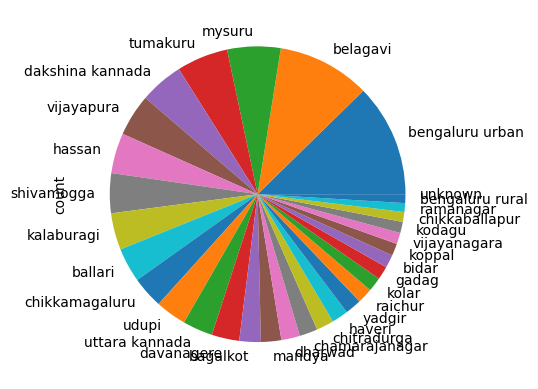

In [194]:
df[df['state'] == 'karnataka']['district'].value_counts().plot(kind='pie')

In [195]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `west bengal`

In [209]:
df_bengal = df[df['state'] == 'west bengal']

In [210]:
df_bengal.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
9,2025-03-01,west bengal,paschim medinipur,721148,13,281,Saturday,March
40,2025-03-01,west bengal,howrah,711303,118,1909,Saturday,March
50,2025-03-01,west bengal,paschim medinipur,721436,10,168,Saturday,March
59,2025-03-01,west bengal,hooghly,712148,35,639,Saturday,March
87,2025-03-01,west bengal,paschim bardhaman,713213,10,201,Saturday,March


In [211]:
df_bengal['district'].value_counts()

district
bardhaman              17876
north 24 parganas      17435
purba medinipur        12371
south 24 parganas      11889
paschim medinipur      10279
hooghly                 9810
howrah                  8827
murshidabad             8055
kolkata                 7089
nadia                   6893
cooch behar             6693
jalpaiguri              6149
malda                   5669
bankura                 5604
darjeeling              5585
purulia                 5069
purba bardhaman         4498
paschim bardhaman       4329
birbhum                 4120
uttar dinajpur          3279
dakshin dinajpur        3250
alipurduar              1794
jhargram                1680
kalimpong                668
midnapore                148
south dumdumm              6
domjur                     2
naihati anandabazar        2
bally jagachha             1
Name: count, dtype: int64

In [212]:
df_bengal['district'].unique()

array(['paschim medinipur', 'howrah', 'hooghly', 'paschim bardhaman',
       'purulia', 'south 24 parganas', 'purba medinipur',
       'north 24 parganas', 'nadia', 'murshidabad', 'kolkata', 'bankura',
       'bardhaman', 'jalpaiguri', 'purba bardhaman', 'uttar dinajpur',
       'darjeeling', 'birbhum', 'malda', 'kalimpong', 'jhargram',
       'cooch behar', 'dakshin dinajpur', 'alipurduar', 'midnapore',
       'south dumdumm', 'bally jagachha', 'domjur', 'naihati anandabazar'],
      dtype=object)

| Variations found                                  | Standard name               |
| ------------------------------------------------- | --------------------------- |
| paschim medinipur, west midnapore, west medinipur | **paschim medinipur**       |
| purba medinipur, east midnapore, east midnapur    | **purba medinipur**         |
| midnapore                                         | ❌ ambiguous → needs context |
| puruliya, purulia                                 | **purulia**                 |
| bardhaman                                         | ❌ ambiguous (split)         |
| paschim bardhaman                                 | **paschim bardhaman**       |
| purba bardhaman                                   | **purba bardhaman**         |
| darjeeling, darjiling                             | **darjeeling**              |
| cooch behar, koch bihar                           | **cooch behar**             |
| malda, maldah                                     | **malda**                   |
| uttar dinajpur, north dinajpur                    | **uttar dinajpur**          |
| dakshin dinajpur, south dinajpur                  | **dakshin dinajpur**        |
| howrah, hawrah                                    | **howrah**                  |


In [200]:
west_bengal_mapping = {
    "west midnapore": "paschim medinipur",
    "west medinipur": "paschim medinipur",
    "paschim medinipur": "paschim medinipur",

    "east midnapore": "purba medinipur",
    "east midnapur": "purba medinipur",
    "purba medinipur": "purba medinipur",

    "puruliya": "purulia",
    "purulia": "purulia",

    "darjiling": "darjeeling",
    "darjeeling": "darjeeling",

    "cooch behar": "cooch behar",
    "koch bihar": "cooch behar",

    "maldah": "malda",
    "malda": "malda",

    "north dinajpur": "uttar dinajpur",
    "uttar dinajpur": "uttar dinajpur",

    "south dinajpur": "dakshin dinajpur",
    "dakshin dinajpur": "dakshin dinajpur",

    "hawrah": "howrah",
    "howrah": "howrah"
}

In [201]:
mask_wb = df['state'].str.lower().str.strip() == 'west bengal'

df.loc[mask_wb, 'district'] = (
    df.loc[mask_wb, 'district']
      .str.lower()
      .str.strip()
      .replace(west_bengal_mapping)
)

In [202]:
df[df['state'] == 'west bengal']['district'].unique()

array(['paschim medinipur', 'howrah', 'hooghly', 'paschim bardhaman',
       'purulia', 'south 24 parganas', 'purba medinipur',
       'north 24 parganas', 'nadia', 'murshidabad', 'kolkata', 'bankura',
       'bardhaman', 'jalpaiguri', 'purba bardhaman', 'uttar dinajpur',
       'darjeeling', 'birbhum', 'malda', 'kalimpong', 'jhargram',
       'cooch behar', 'dakshin dinajpur', 'alipurduar', 'midnapore',
       'south dumdumm', 'bally jagachha', 'domjur', 'naihati anandabazar'],
      dtype=object)

In [213]:
df_bengal.to_csv('west_bengal.csv')

In [214]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `Telangana`

In [224]:
df_telangana = df[df['state'] == 'telangana']

In [225]:
df_telangana.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
12,2025-03-01,telangana,mulugu,506172,24,281,Saturday,March
76,2025-03-01,telangana,karimnagar,505452,39,138,Saturday,March
79,2025-03-01,telangana,hyderabad,500012,21,157,Saturday,March
89,2025-03-01,telangana,nalgonda,508105,29,78,Saturday,March
118,2025-03-01,telangana,narayanpet,509130,22,120,Saturday,March


In [226]:
df_telangana['district'].value_counts()

district
rangareddy                 12717
warangal                   12609
mahbubnagar                12100
karimnagar                 10683
hyderabad                  10010
medak                       9196
nalgonda                    9158
khammam                     8162
adilabad                    7005
nizamabad                   5841
medchal malkajgiri          3031
sangareddy                  2518
siddipet                    2485
hanumakonda                 2125
bhadradri kothagudem        1870
jangaon                     1660
kamareddy                   1657
mancherial                  1646
nagarkurnool                1622
vikarabad                   1599
jagtial                     1591
suryapet                    1471
mahabubabad                 1301
yadadri bhuvanagiri         1283
peddapalli                  1235
narayanpet                  1116
wanaparthy                  1052
nirmal                      1043
rajanna sircilla            1000
mulugu                       859
j

In [227]:
df_telangana['district'].unique()

array(['mulugu', 'karimnagar', 'hyderabad', 'nalgonda', 'narayanpet',
       'sangareddy', 'khammam', 'rangareddy', 'warangal',
       'medchal malkajgiri', 'medak', 'nagarkurnool', 'peddapalli',
       'adilabad', 'vikarabad', 'hanumakonda', 'jogulamba gadwal',
       'siddipet', 'bhadradri kothagudem', 'mahbubnagar', 'jagtial',
       'nizamabad', 'yadadri bhuvanagiri', 'kamareddy', 'suryapet',
       'jangaon', 'mancherial', 'nirmal', 'komaram bheem asifabad',
       'wanaparthy', 'mahabubabad', 'jayashankar bhupalpally',
       'rajanna sircilla', 'unknown'], dtype=object)

| Variations found                      | Standard name               |
| ------------------------------------- | --------------------------- |
| mahbubnagar, mahabubnagar             | **mahbubnagar**             |
| jagitial                              | **jagtial**                 |
| yadadri                               | **yadadri bhuvanagiri**     |
| medchalmalkajgiri, medchalâmalkajgiri | **medchal malkajgiri**      |
| jangoan, jangaon                      | **jangaon**                 |
| komaram bheem                         | **komaram bheem asifabad**  |
| jayashankar bhupalpally               | **jayashankar bhupalpally** |
| warangal                              | ❌ ambiguous                 |
| warangal rural                        | ❌ old                       |
| warangal urban                        | ❌ old                       |


In [220]:
telangana_mapping = {
    "mahabubnagar": "mahbubnagar",
    "mahbubnagar": "mahbubnagar",

    "jagitial": "jagtial",

    "yadadri": "yadadri bhuvanagiri",

    "medchalmalkajgiri": "medchal malkajgiri",
    "medchalâmalkajgiri": "medchal malkajgiri",

    "jangoan": "jangaon",
    "jangaon": "jangaon",

    "komaram bheem": "komaram bheem asifabad",

    "warangal rural": "warangal",
    "warangal urban": "warangal",
    "warangal": "warangal"
}

In [221]:
mask_tg = df['state'].str.lower().str.strip() == 'telangana'

df.loc[mask_tg, 'district'] = (
    df.loc[mask_tg, 'district']
      .str.lower()
      .str.strip()
      .replace(telangana_mapping)
)

In [229]:
df[df['state'] == 'telangana']['district'].unique()

array(['mulugu', 'karimnagar', 'hyderabad', 'nalgonda', 'narayanpet',
       'sangareddy', 'khammam', 'rangareddy', 'warangal',
       'medchal malkajgiri', 'medak', 'nagarkurnool', 'peddapalli',
       'adilabad', 'vikarabad', 'hanumakonda', 'jogulamba gadwal',
       'siddipet', 'bhadradri kothagudem', 'mahbubnagar', 'jagtial',
       'nizamabad', 'yadadri bhuvanagiri', 'kamareddy', 'suryapet',
       'jangaon', 'mancherial', 'nirmal', 'komaram bheem asifabad',
       'wanaparthy', 'mahabubabad', 'jayashankar bhupalpally',
       'rajanna sircilla', 'unknown'], dtype=object)

In [230]:
df_telangana.to_csv('telangana.csv')

In [231]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `orissa`

In [243]:
df_orissa = df[df['state'] == 'orissa']

In [244]:
df_orissa.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
14,2025-03-01,orissa,nayagarh,752081,48,295,Saturday,March
31,2025-03-01,orissa,nabarangapur,764077,37,465,Saturday,March
63,2025-03-01,orissa,koraput,764039,42,432,Saturday,March
93,2025-03-01,orissa,ganjam,761012,54,422,Saturday,March
134,2025-03-01,orissa,koraput,764056,93,779,Saturday,March


In [245]:
df_orissa['district'].unique()

array(['nayagarh', 'nabarangapur', 'koraput', 'ganjam', 'mayurbhanj',
       'sambalpur', 'kendrapara', 'kendujhar', 'bhadrak', 'jajpur',
       'balasore', 'dhenkanal', 'puri', 'khordha', 'gajapati', 'angul',
       'nuapada', 'cuttack', 'boudh', 'jagatsinghpur', 'balangir',
       'jharsuguda', 'kalahandi', 'sundargarh', 'rayagada', 'deogarh',
       'subarnapur', 'bargarh', 'malkangiri', 'kandhamal'], dtype=object)

| Variations found              | Standard name     |
| ----------------------------- | ----------------- |
| jajpur, jajapur, jajapur      | **jajpur**        |
| baleswar, baleshwar           | **balasore**      |
| khorda, khordha               | **khordha**       |
| kendujhar                     | **kendujhar**     |
| anugul, anugal, angul         | **angul**         |
| baudh, boudh                  | **boudh**         |
| jagatsinghapur, jagatsinghpur | **jagatsinghpur** |
| sundergarh, sundargarh        | **sundargarh**    |
| debagarh, debagarh            | **deogarh**       |
| sonapur, subarnapur           | **subarnapur**    |
| bhadrakr                      | **bhadrak**       |


In [235]:
odisha_mapping = {
    "jajapur": "jajpur",
    "jajapur ": "jajpur",
    "jajpur": "jajpur",

    "baleshwar": "balasore",
    "baleswar": "balasore",

    "khorda": "khordha",
    "khordha": "khordha",

    "anugul": "angul",
    "anugal": "angul",
    "angul": "angul",

    "baudh": "boudh",
    "boudh": "boudh",

    "jagatsinghapur": "jagatsinghpur",

    "sundergarh": "sundargarh",
    "sundargarh": "sundargarh",

    "debagarh": "deogarh",

    "sonapur": "subarnapur",

    "bhadrakr": "bhadrak"
}


In [236]:
mask_od = df['state'].str.lower().str.strip() == 'orissa'

df.loc[mask_od, 'district'] = (
    df.loc[mask_od, 'district']
      .str.lower()
      .str.strip()
      .replace(odisha_mapping)
)

In [242]:
len(df[df['state'] == 'orissa']['district'].unique())

30

In [240]:
df['district'] = df['district'].str.replace('balianta','khordha')

In [246]:
df_orissa.to_csv('Odisha.csv')

In [247]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `maharashtra`

In [261]:
df_maharashtra = df[df['state'] == 'maharashtra']

In [249]:
df_maharashtra.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
15,2025-03-01,maharashtra,nashik,422305,13,227,Saturday,March
29,2025-03-01,maharashtra,jalgaon,425310,30,685,Saturday,March
84,2025-03-01,maharashtra,nagpur,440007,10,57,Saturday,March
110,2025-03-01,maharashtra,mumbai,400097,28,675,Saturday,March
152,2025-03-01,maharashtra,solapur,413214,22,331,Saturday,March


In [250]:
df_maharashtra['district'].unique()

array(['nashik', 'jalgaon', 'nagpur', 'mumbai', 'solapur', 'palghar',
       'amravati', 'parbhani', 'jalna', 'ahmadnagar', 'ratnagiri',
       'mumbai suburban', 'pune', 'buldhana', 'satara', 'chandrapur',
       'chhatrapati sambhajinagar', 'osmanabad', 'yavatmal', 'latur',
       'nandurbar', 'kolhapur', 'thane', 'raigarh', 'akola', 'beed',
       'dhule', 'nanded', 'gadchiroli', 'mumbai city', 'raigad',
       'sindhudurg', 'washim', 'sangli', 'gondia', 'wardha',
       'ahmed nagar', 'bhandara', 'dharashiv', 'gondiya ', 'hingoli',
       'mumbai sub urban ', 'chatrapati sambhaji nagar', 'nandurbar ',
       'raigarhmh', 'washim ', 'ahilyanagar', 'unknown', 'hingoli '],
      dtype=object)

| Variations found                                     | Standard name                 |
| ---------------------------------------------------- | ----------------------------- |
| ahmadnagar, ahmed nagar                              | **ahilyanagar**               |
| chhatrapati sambhajinagar, chatrapati sambhaji nagar | **chhatrapati sambhajinagar** |
| osmanabad                                            | **dharashiv**                 |
| gondia, gondiya                                      | **gondia**                    |
| raigarh, raigad, raigarhmh                           | **raigad**                    |
| mumbai sub urban, mumbai suburban                    | **mumbai suburban**           |
| nandurbar                                            | **nandurbar**                 |
| hingoli                                              | **hingoli**                   |
| washin, washim                                       | **washim**                    |


In [251]:
maharashtra_mapping = {
    "ahmadnagar": "ahilyanagar",
    "ahmed nagar": "ahilyanagar",
    "ahilyanagar": "ahilyanagar",

    "chhatrapati sambhajinagar": "chhatrapati sambhajinagar",
    "chatrapati sambhaji nagar": "chhatrapati sambhajinagar",

    "osmanabad": "dharashiv",
    "dharashiv": "dharashiv",

    "gondiya": "gondia",
    "gondia ": "gondia",

    "raigarh": "raigad",
    "raigarhmh": "raigad",
    "raigad": "raigad",

    "mumbai sub urban": "mumbai suburban",
    "mumbai suburban": "mumbai suburban",

    "nandurbar ": "nandurbar",
    "washim ": "washim",
    "hingoli ": "hingoli"
}

In [252]:
mask_mh = df['state'].str.lower().str.strip() == 'maharashtra'

df.loc[mask_mh, 'district'] = (
    df.loc[mask_mh, 'district']
      .str.lower()
      .str.strip()
      .replace(maharashtra_mapping)
)

In [259]:
len(df[df['state'] == 'maharashtra']['district'].unique())

36

In [257]:
df['district'] = df['district'].str.replace('mumbai suburban','mumbai')
df['district'] = df['district'].str.replace('mumbai city','mumbai')

In [260]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

In [262]:
df_maharashtra.to_csv('maharashtra.csv')

### `kerala`

In [270]:
df_kerala = df[df['state'] == 'kerala']

In [264]:
df_kerala.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
17,2025-03-01,kerala,thrissur,680305,11,72,Saturday,March
109,2025-03-01,kerala,kasaragod,671310,20,239,Saturday,March
167,2025-03-01,kerala,malappuram,676541,31,242,Saturday,March
218,2025-03-01,kerala,ernakulam,683594,11,149,Saturday,March
230,2025-03-01,kerala,ernakulam,683501,11,180,Saturday,March


In [265]:
df_kerala['district'].unique()

array(['thrissur', 'kasaragod', 'malappuram', 'ernakulam', 'kannur',
       'alappuzha', 'unknown', 'kozhikode', 'thiruvananthapuram',
       'palakkad', 'wayanad', 'kottayam', 'kollam', 'idukki', 'kasargod'],
      dtype=object)

In [266]:
kerala_mapping = {
    "kasargod": "kasaragod",
    "kasaragod": "kasaragod"
}

In [267]:
mask_kl = df['state'].str.lower().str.strip() == 'kerala'

df.loc[mask_kl, 'district'] = (
    df.loc[mask_kl, 'district']
      .str.lower()
      .str.strip()
      .replace(kerala_mapping)
)

In [269]:
len(df[df['state'] == 'kerala']['district'].unique())

14

In [271]:
df_kerala.to_csv('kerala.csv')

In [272]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `bihar`

In [274]:
df_bihar = df[df['state'] == 'bihar']

In [275]:
df_bihar['district'].unique()

array(['patna', 'jamui', 'gaya', 'darbhanga', 'purnia', 'sheikhpura',
       'sitamarhi', 'muzaffarpur', 'saran', 'gopalganj', 'araria',
       'katihar', 'bhojpur', 'madhubani', 'nawada', 'samastipur', 'buxar',
       'west champaran', 'khagaria', 'east champaran', 'saharsa',
       'rohtas', 'munger', 'arwal', 'siwan', 'kaimur bhabua', 'vaishali',
       'begusarai', 'nalanda', 'supaul', 'chhatrapati sambhajinagar',
       'jehanabad', 'madhepura', 'bhagalpur', 'lakhisarai', 'banka',
       'sheohar', 'kishanganj', 'purba champaran', 'sheikpura',
       'pashchim champaran', 'samstipur', 'aurangabadbh', 'monghyr',
       'bhabua', 'unknown'], dtype=object)

| Variations found                   | Standard name          |
| ---------------------------------- | ---------------------- |
| sheikhpura, sheikpura              | **sheikhpura**         |
| samstipur, samastipur              | **samastipur**         |
| east champaran, purba champaran    | **purba champaran**    |
| west champaran, pashchim champaran | **pashchim champaran** |
| kaimur bhabua, bhabua              | **kaimur**             |
| monghyr                            | **munger**             |
| aurangabadbh                       | **aurangabad**         |


In [276]:
bihar_mapping = {
    "sheikpura": "sheikhpura",

    "samstipur": "samastipur",

    "east champaran": "purba champaran",
    "purba champaran": "purba champaran",

    "west champaran": "pashchim champaran",
    "pashchim champaran": "pashchim champaran",

    "kaimur bhabua": "kaimur",
    "bhabua": "kaimur",

    "monghyr": "munger",

    "aurangabadbh": "aurangabad"
}


In [277]:
mask_br = df['state'].str.lower().str.strip() == 'bihar'

df.loc[mask_br, 'district'] = (
    df.loc[mask_br, 'district']
      .str.lower()
      .str.strip()
      .replace(bihar_mapping)
)

In [278]:
df[df['state'] == 'bihar']['district'].unique()

array(['patna', 'jamui', 'gaya', 'darbhanga', 'purnia', 'sheikhpura',
       'sitamarhi', 'muzaffarpur', 'saran', 'gopalganj', 'araria',
       'katihar', 'bhojpur', 'madhubani', 'nawada', 'samastipur', 'buxar',
       'pashchim champaran', 'khagaria', 'purba champaran', 'saharsa',
       'rohtas', 'munger', 'arwal', 'siwan', 'kaimur', 'vaishali',
       'begusarai', 'nalanda', 'supaul', 'chhatrapati sambhajinagar',
       'jehanabad', 'madhepura', 'bhagalpur', 'lakhisarai', 'banka',
       'sheohar', 'kishanganj', 'aurangabad', 'unknown'], dtype=object)

| Item                        | Status    |
| --------------------------- | --------- |
| Bihar districts             | ✅ Correct |
| `unknown`                   | ❌ Remove  |
| `chhatrapati sambhajinagar` | ❌ Remove  |


In [280]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `tamil nadu`

In [281]:
df_tamil = df[df['state'] == 'tamil nadu']

In [282]:
df_tamil.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
21,2025-03-01,tamil nadu,kancheepuram,603202,42,700,Saturday,March
23,2025-03-01,tamil nadu,chennai,600006,16,128,Saturday,March
28,2025-03-01,tamil nadu,tiruppur,641606,54,639,Saturday,March
46,2025-03-01,tamil nadu,nagapattinam,611001,21,379,Saturday,March
56,2025-03-01,tamil nadu,kanyakumari,629803,10,19,Saturday,March


In [283]:
df_tamil['district'].unique()

array(['kancheepuram', 'chennai', 'tiruppur', 'nagapattinam',
       'kanyakumari', 'salem', 'cuddalore', 'tiruchirappalli',
       'tiruvannamalai', 'dindigul', 'tenkasi', 'krishnagiri',
       'kallakurichi', 'tiruvallur', 'erode', 'coimbatore',
       'virudhunagar', 'namakkal', 'vellore', 'ramanathapuram',
       'tirunelveli', 'villupuram', 'dharmapuri', 'ariyalur', 'theni',
       'tirupattur', 'thiruvarur', 'karur', 'pudukkottai', 'sivaganga',
       'kanniyakumari', 'madurai', 'viluppuram', 'thanjavur',
       'thoothukkudi', 'ranipet', 'the nilgiris', 'chengalpattu',
       'mayiladuthurai', 'perambalur', 'thiruvallur', 'tirupathur',
       'kanchipuram', 'tuticorin', 'tiruvarur', 'unknown'], dtype=object)

| Variations found           | Standard name    |
| -------------------------- | ---------------- |
| kancheepuram, kanchipuram  | **kanchipuram**  |
| kanniyakumari, kanyakumari | **kanyakumari**  |
| villupuram, viluppuram     | **viluppuram**   |
| tiruvallur, thiruvallur    | **tiruvallur**   |
| tirupattur, tirupathur     | **tirupattur**   |
| thoothukkudi, tuticorin    | **thoothukkudi** |
| the nilgiris               | **nilgiris**     |
| tiruvarur, thiruvarur      | **tiruvarur**    |


In [284]:
tamilnadu_mapping = {
    "kancheepuram": "kanchipuram",
    "kanchipuram": "kanchipuram",

    "kanniyakumari": "kanyakumari",
    "kanyakumari": "kanyakumari",

    "villupuram": "viluppuram",
    "viluppuram": "viluppuram",

    "thiruvallur": "tiruvallur",
    "tiruvallur": "tiruvallur",

    "tirupathur": "tirupattur",
    "tirupattur": "tirupattur",

    "tuticorin": "thoothukkudi",
    "thoothukkudi": "thoothukkudi",

    "the nilgiris": "nilgiris",

    "thiruvarur": "tiruvarur",
    "tiruvarur": "tiruvarur"
}

In [285]:
mask_tn = df['state'].str.lower().str.strip() == 'tamil nadu'

df.loc[mask_tn, 'district'] = (
    df.loc[mask_tn, 'district']
      .str.lower()
      .str.strip()
      .replace(tamilnadu_mapping)
)

In [286]:
df[df['state'] == 'tamil nadu']['district'].unique()

array(['kanchipuram', 'chennai', 'tiruppur', 'nagapattinam',
       'kanyakumari', 'salem', 'cuddalore', 'tiruchirappalli',
       'tiruvannamalai', 'dindigul', 'tenkasi', 'krishnagiri',
       'kallakurichi', 'tiruvallur', 'erode', 'coimbatore',
       'virudhunagar', 'namakkal', 'vellore', 'ramanathapuram',
       'tirunelveli', 'viluppuram', 'dharmapuri', 'ariyalur', 'theni',
       'tirupattur', 'tiruvarur', 'karur', 'pudukkottai', 'sivaganga',
       'madurai', 'thanjavur', 'thoothukkudi', 'ranipet', 'nilgiris',
       'chengalpattu', 'mayiladuthurai', 'perambalur', 'unknown'],
      dtype=object)

In [287]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `madhya pradesh`

In [293]:
df_madhya_pradesh = df[df['state'] == 'madhya pradesh']

In [289]:
df_madhya_pradesh.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
22,2025-03-01,madhya pradesh,jabalpur,483119,132,1228,Saturday,March
107,2025-03-01,madhya pradesh,indore,452020,110,858,Saturday,March
129,2025-03-01,madhya pradesh,betul,460110,140,753,Saturday,March
130,2025-03-01,madhya pradesh,satna,485001,227,1621,Saturday,March
131,2025-03-01,madhya pradesh,indore,452010,275,1991,Saturday,March


In [290]:
df_madhya_pradesh['district'].unique()

array(['jabalpur', 'indore', 'betul', 'satna', 'tikamgarh', 'khargone',
       'rewa', 'chhatarpur', 'chhindwara', 'agar malwa', 'gwalior',
       'umaria', 'damoh', 'maihar', 'shajapur', 'guna', 'hoshangabad',
       'sehore', 'narsinghpur', 'mandsaur', 'neemuch', 'niwari',
       'east nimar', 'bhopal', 'datia', 'seoni', 'ujjain', 'rajgarh',
       'katni', 'narmadapuram', 'barwani', 'mandla', 'shivpuri',
       'burhanpur', 'dhar', 'shahdol', 'balaghat', 'dindori', 'sagar',
       'raisen', 'anuppur', 'vidisha', 'dewas', 'ratlam', 'ashok nagar',
       'sidhi', 'jhabua', 'harda', 'bhind', 'alirajpur', 'panna',
       'singrauli', 'khandwa', 'west nimar', 'morena', 'narsimhapur',
       'mauganj', 'sheopur', 'harda ', 'pandhurna'], dtype=object)

| Variations found         | Standard name    |
| ------------------------ | ---------------- |
| hoshangabad              | **narmadapuram** |
| narsinghpur, narsimhapur | **narsinghpur**  |
| east nimar               | **khandwa**      |
| west nimar               | **khargone**     |
| harda, harda             | **harda**        |


In [291]:
madhya_pradesh_mapping = {
    "hoshangabad": "narmadapuram",

    "narsimhapur": "narsinghpur",
    "narsinghpur": "narsinghpur",

    "east nimar": "khandwa",
    "west nimar": "khargone",

    "harda ": "harda"
}

In [292]:
mask_mp = df['state'].str.lower().str.strip() == 'madhya pradesh'

df.loc[mask_mp, 'district'] = (
    df.loc[mask_mp, 'district']
      .str.lower()
      .str.strip()
      .replace(madhya_pradesh_mapping)
)

In [295]:
df[df['state'] == 'madhya pradesh']['district'].unique()

array(['jabalpur', 'indore', 'betul', 'satna', 'tikamgarh', 'khargone',
       'rewa', 'chhatarpur', 'chhindwara', 'agar malwa', 'gwalior',
       'umaria', 'damoh', 'maihar', 'shajapur', 'guna', 'narmadapuram',
       'sehore', 'narsinghpur', 'mandsaur', 'neemuch', 'niwari',
       'khandwa', 'bhopal', 'datia', 'seoni', 'ujjain', 'rajgarh',
       'katni', 'barwani', 'mandla', 'shivpuri', 'burhanpur', 'dhar',
       'shahdol', 'balaghat', 'dindori', 'sagar', 'raisen', 'anuppur',
       'vidisha', 'dewas', 'ratlam', 'ashok nagar', 'sidhi', 'jhabua',
       'harda', 'bhind', 'alirajpur', 'panna', 'singrauli', 'morena',
       'mauganj', 'sheopur', 'pandhurna'], dtype=object)

In [296]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `assam`

In [298]:
df_assam = df[df['state'] == 'assam']

In [300]:
df_assam.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
24,2025-03-01,assam,tinsukia,786174,22,416,Saturday,March
271,2025-03-01,assam,charaideo,785693,16,190,Saturday,March
287,2025-03-01,assam,udalguri,784114,42,343,Saturday,March
289,2025-03-01,assam,nalbari,781371,10,143,Saturday,March
296,2025-03-01,assam,karimganj,788726,11,160,Saturday,March


In [301]:
df_assam['district'].unique()

array(['tinsukia', 'charaideo', 'udalguri', 'nalbari', 'karimganj',
       'nagaon', 'lakhimpur', 'karbi anglong', 'goalpara', 'hailakandi',
       'barpeta', 'golaghat', 'marigaon', 'kamrup metro', 'sonitpur',
       'dibrugarh', 'jorhat', 'cachar', 'baksa', 'sibsagar', 'bongaigaon',
       'kokrajhar', 'dhubri', 'darrang', 'dhemaji', 'hojai',
       'south salmara mankachar', 'north cachar hills', 'kamrup',
       'biswanath', 'majuli', 'sribhumi', 'unknown', 'west karbi anglong',
       'bajali', 'chirang', 'dima hasao'], dtype=object)

| Variations found   | Standard name           |
| ------------------ | ----------------------- |
| sibsagar           | **sivasagar**           |
| marigaon           | **morigaon**            |
| north cachar hills | **dima hasao**          |
| kamrup metro       | **kamrup metropolitan** |


In [302]:
assam_mapping = {
    "sibsagar": "sivasagar",
    "marigaon": "morigaon",
    "north cachar hills": "dima hasao",
    "kamrup metro": "kamrup metropolitan"
}


In [303]:
mask_as = df['state'].str.lower().str.strip() == 'assam'

df.loc[mask_as, 'district'] = (
    df.loc[mask_as, 'district']
      .str.lower()
      .str.strip()
      .replace(assam_mapping)
)

In [304]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `tripura`

In [305]:
df_tripura = df[df['state'] == 'tripura']

In [306]:
df_tripura.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
30,2025-03-01,tripura,dhalai,799285,18,517,Saturday,March
205,2025-03-01,tripura,unakoti,799279,15,90,Saturday,March
1972,2025-03-01,tripura,khowai,799205,34,382,Saturday,March
2106,2025-03-01,tripura,west tripura,799001,43,510,Saturday,March
2444,2025-03-01,tripura,west tripura,799008,31,297,Saturday,March


In [307]:
df_tripura['district'].unique()

array(['dhalai', 'unakoti', 'khowai', 'west tripura', 'south tripura',
       'north tripura', 'gomati', 'sepahijala', 'dhalai '], dtype=object)

In [308]:
tripura_mapping = {
    "dhalai ": "dhalai"
}

In [309]:
mask_tr = df['state'].str.lower().str.strip() == 'tripura'

df.loc[mask_tr, 'district'] = (
    df.loc[mask_tr, 'district']
      .str.lower()
      .str.strip()
      .replace(tripura_mapping)
)

In [310]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `arunachal pradesh`

In [311]:
df_arunachal = df[df['state'] == 'arunachal pradesh']

In [312]:
df_arunachal.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
42,2025-03-01,arunachal pradesh,west kameng,790001,13,44,Saturday,March
91,2025-03-01,arunachal pradesh,tawang,790106,14,64,Saturday,March
2871,2025-03-01,arunachal pradesh,lohit,792001,20,107,Saturday,March
2891,2025-03-01,arunachal pradesh,west kameng,790101,12,72,Saturday,March
3233,2025-03-01,arunachal pradesh,kra daadi,791118,26,105,Saturday,March


In [313]:
df_arunachal['district'].unique()

array(['west kameng', 'tawang', 'lohit', 'kra daadi', 'upper siang',
       'anjaw', 'changlang', 'east siang', 'kamle', 'longding',
       'west siang', 'namsai', 'tirap', 'upper subansiri', 'east kameng',
       'kurung kumey', 'lower siang', 'lower subansiri', 'papum pare',
       'siang', 'dibang valley', 'lower dibang valley', 'leparada',
       'shiyomi', 'pakke kessang'], dtype=object)

In [314]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `Punjab`

In [315]:
df_punjab = df[df['state'] == 'punjab']

In [316]:
df_punjab.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
49,2025-03-01,punjab,amritsar,143119,10,197,Saturday,March
69,2025-03-01,punjab,jalandhar,144002,59,1046,Saturday,March
72,2025-03-01,punjab,jalandhar,144009,36,308,Saturday,March
125,2025-03-01,punjab,firozpur,152022,14,325,Saturday,March
182,2025-03-01,punjab,ludhiana,141017,10,133,Saturday,March


In [317]:
df_punjab['district'].unique()

array(['amritsar', 'jalandhar', 'firozpur', 'ludhiana',
       'sri muktsar sahib', 'moga', 'rupnagar', 'bathinda', 'patiala',
       'kapurthala', 'sangrur', 'sas nagar mohali', 'fazilka',
       'gurdaspur', 'ferozepur', 'hoshiarpur', 'tarn taran', 'pathankot',
       'faridkot', 'mansa', 'malerkotla', 'barnala', 'fatehgarh sahib',
       'muktsar', 'nawanshahr', 'sas nagarmohali',
       'shaheed bhagat singh nagar'], dtype=object)

| Variations found                       | Standard (official) name       |
| -------------------------------------- | ------------------------------ |
| firozpur, ferozepur                    | **ferozepur**                  |
| sri muktsar sahib, muktsar             | **sri muktsar sahib**          |
| sas nagar mohali, sas nagarmohali      | **sahibzada ajit singh nagar** |
| nawanshahr, shaheed bhagat singh nagar | **shaheed bhagat singh nagar** |

In [318]:
punjab_mapping = {
    "firozpur": "ferozepur",
    "ferozepur": "ferozepur",

    "muktsar": "sri muktsar sahib",
    "sri muktsar sahib": "sri muktsar sahib",

    "sas nagar mohali": "sahibzada ajit singh nagar",
    "sas nagarmohali": "sahibzada ajit singh nagar",

    "nawanshahr": "shaheed bhagat singh nagar",
    "shaheed bhagat singh nagar": "shaheed bhagat singh nagar"
}

In [319]:
mask_pb = df['state'].str.lower().str.strip() == 'punjab'

df.loc[mask_pb, 'district'] = (
    df.loc[mask_pb, 'district']
      .str.lower()
      .str.strip()
      .replace(punjab_mapping)
)

In [320]:
df[df['state'] == 'punjab']['district'].unique()

array(['amritsar', 'jalandhar', 'ferozepur', 'ludhiana',
       'sri muktsar sahib', 'moga', 'rupnagar', 'bathinda', 'patiala',
       'kapurthala', 'sangrur', 'sahibzada ajit singh nagar', 'fazilka',
       'gurdaspur', 'hoshiarpur', 'tarn taran', 'pathankot', 'faridkot',
       'mansa', 'malerkotla', 'barnala', 'fatehgarh sahib',
       'shaheed bhagat singh nagar'], dtype=object)

In [321]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `jharkhand`

In [322]:
df_jharkhand = df[df['state'] == 'jharkhand']

In [323]:
df_jharkhand.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
54,2025-03-01,jharkhand,khunti,835234,19,425,Saturday,March
62,2025-03-01,jharkhand,giridih,825320,98,2931,Saturday,March
97,2025-03-01,jharkhand,dhanbad,828203,35,1200,Saturday,March
157,2025-03-01,jharkhand,bokaro,827010,59,2267,Saturday,March
311,2025-03-01,jharkhand,east singhbhum,831006,25,509,Saturday,March


In [324]:
df_jharkhand['district'].unique()

array(['khunti', 'giridih', 'dhanbad', 'bokaro', 'east singhbhum',
       'latehar', 'garhwa', 'lohardaga', 'simdega', 'gumla', 'palamu',
       'deoghar', 'dumka', 'sahebganj', 'kodarma', 'hazaribagh',
       'west singhbhum', 'seraikelakharsawan', 'ranchi', 'godda',
       'chatra', 'koderma', 'garhwa ', 'hazaribag', 'jamtara', 'pakaur',
       'pakur', 'palamau', 'purbi singhbhum', 'ramgarh',
       'pashchimi singhbhum', 'sahibganj'], dtype=object)

| Variations found      | Standard name           |
| --------------------- | ----------------------- |
| kodarma, koderma      | **koderma**             |
| hazaribag, hazaribagh | **hazaribagh**          |
| garhwa, garhwa        | **garhwa**              |
| palamu, palamau       | **palamu**              |
| pakur, pakaur         | **pakur**               |
| purbi singhbhum       | **east singhbhum**      |
| pashchimi singhbhum   | **west singhbhum**      |
| seraikelakharsawan    | **seraikela kharsawan** |
| sahebganj, sahibganj  | **sahebganj**           |


In [325]:
jharkhand_mapping = {
    "kodarma": "koderma",

    "hazaribag": "hazaribagh",
    "hazaribagh": "hazaribagh",

    "garhwa ": "garhwa",

    "palamau": "palamu",

    "pakaur": "pakur",

    "purbi singhbhum": "east singhbhum",
    "pashchimi singhbhum": "west singhbhum",

    "seraikelakharsawan": "seraikela kharsawan",

    "sahibganj": "sahebganj"
}

In [326]:
mask_jh = df['state'].str.lower().str.strip() == 'jharkhand'

df.loc[mask_jh, 'district'] = (
    df.loc[mask_jh, 'district']
      .str.lower()
      .str.strip()
      .replace(jharkhand_mapping)
)

In [328]:
df[df['state'] == 'jharkhand']['district'].unique()

array(['khunti', 'giridih', 'dhanbad', 'bokaro', 'east singhbhum',
       'latehar', 'garhwa', 'lohardaga', 'simdega', 'gumla', 'palamu',
       'deoghar', 'dumka', 'sahebganj', 'koderma', 'hazaribagh',
       'west singhbhum', 'seraikela kharsawan', 'ranchi', 'godda',
       'chatra', 'jamtara', 'pakur', 'ramgarh'], dtype=object)

In [329]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `Delhi`

In [330]:
df_delhi = df[df['state'] == 'delhi']

In [331]:
df_delhi.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
60,2025-03-01,delhi,central delhi,110055,109,1458,Saturday,March
124,2025-03-01,delhi,north east delhi,110094,1013,7227,Saturday,March
179,2025-03-01,delhi,south delhi,110024,18,426,Saturday,March
220,2025-03-01,delhi,south west delhi,110045,402,4205,Saturday,March
488,2025-03-01,delhi,south west delhi,110029,20,308,Saturday,March


In [332]:
df_delhi['district'].unique()

array(['central delhi', 'north east delhi', 'south delhi',
       'south west delhi', 'north west delhi', 'east delhi', 'shahdara',
       'north delhi', 'west delhi', 'najafgarh', 'new delhi',
       'north east', 'south east delhi'], dtype=object)

In [333]:
delhi_mapping = {
    "north east": "north east delhi",
    "north east delhi": "north east delhi",
}


In [334]:
mask_dl = df['state'].str.lower().str.strip() == 'delhi'

df.loc[mask_dl, 'district'] = (
    df.loc[mask_dl, 'district']
      .str.lower()
      .str.strip()
      .replace(delhi_mapping)
)
df = df[~df['district'].isin(['najafgarh', 'new delhi'])]

In [336]:
df[df['state'] == 'delhi']['district'].unique()

array(['central delhi', 'north east delhi', 'south delhi',
       'south west delhi', 'north west delhi', 'east delhi', 'shahdara',
       'north delhi', 'west delhi', 'south east delhi'], dtype=object)

In [337]:
df.to_csv('at_that_point.csv',index=False)

In [338]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `chandigarh`

In [339]:
df_chandigarh = df[df['state'] == 'chandigarh']

In [340]:
df_chandigarh.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
86,2025-03-01,chandigarh,chandigarh,160103,12,78,Saturday,March
123,2025-03-01,chandigarh,chandigarh,160003,31,149,Saturday,March
990,2025-04-01,chandigarh,chandigarh,160002,246,641,Tuesday,April
1024,2025-04-01,chandigarh,chandigarh,160102,382,697,Tuesday,April
1147,2025-04-01,chandigarh,chandigarh,160022,71,321,Tuesday,April


In [341]:
df_chandigarh['district'].unique()

array(['chandigarh', 'rupnagar', 'mohali'], dtype=object)

In [342]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `chhattisgarh`

In [343]:
df_chhattisgarh = df[df['state'] == 'chhattisgarh']

In [344]:
df_chhattisgarh.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
95,2025-03-01,chhattisgarh,kawardha,491888,13,375,Saturday,March
460,2025-03-01,chhattisgarh,baloda bazar,493331,10,437,Saturday,March
517,2025-03-01,chhattisgarh,kabeerdham,491559,24,546,Saturday,March
610,2025-03-01,chhattisgarh,jashpur,496118,125,961,Saturday,March
791,2025-03-01,chhattisgarh,kanker,494635,31,336,Saturday,March


In [345]:
df_chhattisgarh['district'].unique()

array(['kawardha', 'baloda bazar', 'kabeerdham', 'jashpur', 'kanker',
       'bastar', 'janjgirchampa', 'mahasamund', 'surguja', 'raipur',
       'balod', 'koriya', 'durg', 'korba', 'mungeli', 'rajnandgaon',
       'balrampur', 'dhamtari', 'raigarh', 'gariyaband', 'bemetara',
       'uttar bastar kanker', 'kondagaon', 'gaurelapendramarwahi',
       'bilaspur', 'surajpur', 'sukma', 'bijapur',
       'mohlamanpurambagarh chouki', 'khairagarh chhuikhadan gandai',
       'dakshin bastar dantewada', 'dantewada',
       'manendragarhchirmiribharatpur', 'sakti', 'sarangarhbilaigarh',
       'janjgir champa', 'janjgir  champa', 'narayanpur',
       'mohallamanpurambagarh chowki'], dtype=object)

| Variations found                                           | Standard (official) name            |
| ---------------------------------------------------------- | ----------------------------------- |
| kawardha, kabeerdham                                       | **kabirdham**                       |
| janjgirchampa, janjgir champa, janjgir  champa             | **janjgir-champa**                  |
| uttar bastar kanker, kanker                                | **kanker**                          |
| dakshin bastar dantewada, dantewada                        | **dantewada**                       |
| mohla-manpur-ambagarh chouki, mohallamanpurambagarh chowki | **mohla-manpur-ambagarh chouki**    |
| manendragarhchirmiribharatpur                              | **manendragarh-chirmiri-bharatpur** |
| khairagarh chhuikhadan gandai                              | **khairagarh-chhuikhadan-gandai**   |
| sarangarhbilaigarh                                         | **sarangarh-bilaigarh**             |
| koriya                                                     | **korea**                           |


In [346]:
chhattisgarh_mapping = {
    "kawardha": "kabirdham",
    "kabeerdham": "kabirdham",

    "janjgirchampa": "janjgir-champa",
    "janjgir champa": "janjgir-champa",
    "janjgir  champa": "janjgir-champa",

    "uttar bastar kanker": "kanker",

    "dakshin bastar dantewada": "dantewada",

    "mohlamanpurambagarh chouki": "mohla-manpur-ambagarh chouki",
    "mohallamanpurambagarh chowki": "mohla-manpur-ambagarh chouki",

    "manendragarhchirmiribharatpur": "manendragarh-chirmiri-bharatpur",

    "khairagarh chhuikhadan gandai": "khairagarh-chhuikhadan-gandai",

    "sarangarhbilaigarh": "sarangarh-bilaigarh",

    "koriya": "korea"
}


In [347]:
mask_cg = df['state'].str.lower().str.strip() == 'chhattisgarh'

df.loc[mask_cg, 'district'] = (
    df.loc[mask_cg, 'district']
      .str.lower()
      .str.strip()
      .replace(chhattisgarh_mapping)
)


In [348]:
df[df['state'] == 'chhattisgarh']['district'].unique()

array(['kabirdham', 'baloda bazar', 'jashpur', 'kanker', 'bastar',
       'janjgir-champa', 'mahasamund', 'surguja', 'raipur', 'balod',
       'korea', 'durg', 'korba', 'mungeli', 'rajnandgaon', 'balrampur',
       'dhamtari', 'raigarh', 'gariyaband', 'bemetara', 'kondagaon',
       'gaurelapendramarwahi', 'bilaspur', 'surajpur', 'sukma', 'bijapur',
       'mohla-manpur-ambagarh chouki', 'khairagarh-chhuikhadan-gandai',
       'dantewada', 'manendragarh-chirmiri-bharatpur', 'sakti',
       'sarangarh-bilaigarh', 'narayanpur'], dtype=object)

In [349]:
df['district'] = df['district'].str.replace('gaurelapendramarwahi','gaurela-pendra-marwahi')

C:\Users\dell g3\AppData\Local\Temp\ipykernel_5204\841447694.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['district'] = df['district'].str.replace('gaurelapendramarwahi','gaurela-pendra-marwahi')


In [350]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `jammu and kashmir`

In [2]:
df.to_csv('last_update.csv',index=False)

NameError: name 'df' is not defined

In [4]:
df = pd.read_csv('last_update.csv')

In [5]:
df.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
0,2025-03-01,uttar pradesh,gorakhpur,273213,49,529,Saturday,March
1,2025-03-01,andhra pradesh,chittoor,517132,22,375,Saturday,March
2,2025-03-01,gujarat,rajkot,360006,65,765,Saturday,March
3,2025-03-01,andhra pradesh,srikakulam,532484,24,314,Saturday,March
4,2025-03-01,rajasthan,udaipur,313801,45,785,Saturday,March


In [6]:
df_jammu = df[df['state'] == 'jammu and kashmir']

In [7]:
df_jammu['district'].unique()

array(['jammu', 'rajouri', 'baramula', 'ganderbal', 'srinagar', 'badgam',
       'kathua', 'anantnag', 'pulwama', 'ramban', 'samba', 'budgam',
       'bandipore', 'kupwara', 'kulgam', 'punch', 'doda', 'kargil',
       'udhampur', 'kishtwar', 'leh', 'reasi', 'shupiyan', 'rajauri',
       'leh ladakh', 'poonch', 'bandipur'], dtype=object)

| Variations found    | Standard name |
| ------------------- | ------------- |
| baramula            | **baramulla** |
| badgam, budgam      | **budgam**    |
| bandipore, bandipur | **bandipora** |
| punch, poonch       | **poonch**    |
| shupiyan            | **shopian**   |
| rajouri, rajauri    | **rajouri**   |
| leh ladakh          | **leh**       |


In [8]:
jk_mapping = {
    "baramula": "baramulla",
    "badgam": "budgam",

    "bandipore": "bandipora",
    "bandipur": "bandipora",

    "punch": "poonch",

    "shupiyan": "shopian",

    "rajauri": "rajouri",

    "leh ladakh": "leh"
}

In [9]:
# normalize text
df['district'] = df['district'].str.lower().str.strip()

# Jammu & Kashmir fixes
mask_jk = df['state'].str.lower().str.strip() == 'jammu and kashmir'
df.loc[mask_jk, 'district'] = df.loc[mask_jk, 'district'].replace(jk_mapping)

# Move Ladakh districts to Ladakh UT
df.loc[df['district'].isin(['leh', 'kargil']), 'state'] = 'ladakh'

In [10]:
df[df['state'] == 'jammu and kashmir']['district'].unique()

array(['jammu', 'rajouri', 'baramulla', 'ganderbal', 'srinagar', 'budgam',
       'kathua', 'anantnag', 'pulwama', 'ramban', 'samba', 'bandipora',
       'kupwara', 'kulgam', 'poonch', 'doda', 'udhampur', 'kishtwar',
       'reasi', 'shopian'], dtype=object)

In [11]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `mizoram`

In [12]:
df_mizoram = df[df['state'] == 'mizoram']

In [13]:
df_mizoram.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
146,2025-03-01,mizoram,aizawl,796036,11,118,Saturday,March
1167,2025-04-01,mizoram,serchhip,796181,76,238,Tuesday,April
1258,2025-05-01,mizoram,kolasib,796081,76,414,Thursday,May
2881,2025-03-01,mizoram,aizawl,796012,59,264,Saturday,March
3006,2025-03-01,mizoram,lunglei,796730,37,369,Saturday,March


In [14]:
df_mizoram['district'].unique()

array(['aizawl', 'serchhip', 'kolasib', 'lunglei', 'mamit', 'saiha',
       'champhai', 'mammit', 'lawngtlai', 'saitual', 'khawzawl',
       'hnahthial'], dtype=object)

In [15]:
mizoram_mapping = {
    "mammit": "mamit"
}

In [16]:
mask_mz = df['state'].str.lower().str.strip() == 'mizoram'

df.loc[mask_mz, 'district'] = (
    df.loc[mask_mz, 'district']
      .str.lower()
      .str.strip()
      .replace(mizoram_mapping)
)

In [17]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `nagaland`

In [18]:
df_nagaland = df[df['state'] == 'nagaland']

In [19]:
df_nagaland.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
161,2025-03-01,nagaland,peren,797110,29,229,Saturday,March
327,2025-03-01,nagaland,chumukedima,797103,18,145,Saturday,March
2270,2025-03-01,nagaland,zunheboto,798620,53,498,Saturday,March
2571,2025-03-01,nagaland,dimapur,797117,12,25,Saturday,March
3815,2025-03-01,nagaland,kiphire,798611,60,682,Saturday,March


In [20]:
df_nagaland['district'].unique()

array(['peren', 'chumukedima', 'zunheboto', 'dimapur', 'kiphire',
       'kohima', 'longleng', 'meluri', 'mokokchung', 'mon', 'tseminyu',
       'phek', 'wokha', 'niuland', 'tuensang', 'noklak', 'shamator'],
      dtype=object)

In [21]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `himachal pradesh`

In [22]:
df_himachal = df[df['state'] == 'himachal pradesh']

In [23]:
df_himachal.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
162,2025-03-01,himachal pradesh,kangra,176056,16,169,Saturday,March
201,2025-03-01,himachal pradesh,sirmaur,173022,86,284,Saturday,March
381,2025-03-01,himachal pradesh,chamba,176315,12,86,Saturday,March
389,2025-03-01,himachal pradesh,kangra,176021,17,212,Saturday,March
504,2025-03-01,himachal pradesh,mandi,175106,12,110,Saturday,March


In [24]:
df_himachal['district'].unique()

array(['kangra', 'sirmaur', 'chamba', 'mandi', 'bilaspur', 'una',
       'shimla', 'solan', 'hamirpur', 'kinnaur', 'kullu',
       'lahul and spiti', 'lahaul and spiti'], dtype=object)

In [25]:
himachal_mapping = {
    "lahul and spiti": "lahaul and spiti"
}

In [26]:
mask_hp = df['state'].str.lower().str.strip() == 'himachal pradesh'

df.loc[mask_hp, 'district'] = (
    df.loc[mask_hp, 'district']
      .str.lower()
      .str.strip()
      .replace(himachal_mapping)
)

In [27]:
df[df['state'] == 'himachal pradesh']['district'].unique()

array(['kangra', 'sirmaur', 'chamba', 'mandi', 'bilaspur', 'una',
       'shimla', 'solan', 'hamirpur', 'kinnaur', 'kullu',
       'lahaul and spiti'], dtype=object)

In [28]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `goa`

In [29]:
df_goa = df[df['state'] == 'goa']

In [30]:
df_goa.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
172,2025-03-01,goa,north goa,403501,14,52,Saturday,March
416,2025-03-01,goa,north goa,403510,10,69,Saturday,March
523,2025-03-01,goa,south goa,403710,12,88,Saturday,March
621,2025-03-01,goa,south goa,403706,17,193,Saturday,March
2225,2025-03-01,goa,north goa,403512,51,139,Saturday,March


In [31]:
df_goa['district'].unique()

array(['north goa', 'south goa', 'bardez', 'tiswadi', 'bicholim'],
      dtype=object)

In [32]:
goa_mapping = {
    "bardez": "north goa",
    "tiswadi": "north goa",
    "bicholim": "north goa"
}

mask_ga = df['state'].str.lower().str.strip() == 'goa'

df.loc[mask_ga, 'district'] = (
    df.loc[mask_ga, 'district']
      .str.lower()
      .str.strip()
      .replace(goa_mapping)
)

In [37]:
df[df['state'] == 'goa']['district'].unique()

array(['north goa', 'south goa'], dtype=object)

In [33]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `haryana`

In [38]:
df_haryana = df[df['state'] == 'haryana']

In [39]:
df_haryana.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
208,2025-03-01,haryana,sonipat,131023,35,327,Saturday,March
249,2025-03-01,haryana,rohtak,124001,277,1617,Saturday,March
298,2025-03-01,haryana,sonipat,131304,13,105,Saturday,March
308,2025-03-01,haryana,gurgaon,122006,44,446,Saturday,March
316,2025-03-01,haryana,kaithal,136033,29,432,Saturday,March


In [36]:
df_haryana['district'].unique()

array(['sonipat', 'rohtak', 'gurgaon', 'kaithal', 'hisar', 'panchkula',
       'karnal', 'ambala', 'rewari', 'jhajjar', 'bhiwani', 'jind',
       'sirsa', 'mewat', 'faridabad', 'yamuna nagar', 'mahendragarh',
       'kurukshetra', 'fatehabad', 'charkhi dadri', 'panipat', 'palwal',
       'yamunanagar'], dtype=object)

In [40]:
haryana_mapping = {
    "yamuna nagar": "yamunanagar",
    "yamunanagar": "yamunanagar",

    "mewat": "nuh"
}

In [41]:
mask_hr = df['state'].str.lower().str.strip() == 'haryana'

df.loc[mask_hr, 'district'] = (
    df.loc[mask_hr, 'district']
      .str.lower()
      .str.strip()
      .replace(haryana_mapping)
)

In [42]:
df[df['state'] == 'haryana']['district'].unique()

array(['sonipat', 'rohtak', 'gurgaon', 'kaithal', 'hisar', 'panchkula',
       'karnal', 'ambala', 'rewari', 'jhajjar', 'bhiwani', 'jind',
       'sirsa', 'nuh', 'faridabad', 'yamunanagar', 'mahendragarh',
       'kurukshetra', 'fatehabad', 'charkhi dadri', 'panipat', 'palwal'],
      dtype=object)

In [43]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `meghalaya`

In [44]:
df_meghalaya = df[df['state'] == 'meghalaya']

In [45]:
df_meghalaya.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
224,2025-03-01,meghalaya,east jaintia hills,793200,82,714,Saturday,March
438,2025-03-01,meghalaya,west garo hills,794001,13,355,Saturday,March
814,2025-03-01,meghalaya,ri bhoi,793105,52,506,Saturday,March
1919,2025-03-01,meghalaya,west khasi hills,793120,78,1149,Saturday,March
2339,2025-03-01,meghalaya,east khasi hills,793021,15,103,Saturday,March


In [46]:
df_meghalaya['district'].unique()

array(['east jaintia hills', 'west garo hills', 'ri bhoi',
       'west khasi hills', 'east khasi hills', 'north garo hills',
       'south garo hills', 'south west garo hills', 'west jaintia hills',
       'east garo hills', 'eastern west khasi hills',
       'south west khasi hills', 'jaintia hills'], dtype=object)

In [47]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `uttarakhand`

In [48]:
df_uttarakhand = df[df['state'] == 'uttarakhand']

In [49]:
df_uttarakhand.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_,day_name,month_name
362,2025-03-01,uttarakhand,pithoragarh,262544,12,135,Saturday,March
448,2025-03-01,uttarakhand,dehradun,248001,354,3503,Saturday,March
521,2025-03-01,uttarakhand,tehri garhwal,249155,115,644,Saturday,March
596,2025-03-01,uttarakhand,nainital,263159,34,235,Saturday,March
853,2025-03-01,uttarakhand,uttarkashi,249171,28,219,Saturday,March


In [50]:
df_uttarakhand['district'].unique()

array(['pithoragarh', 'dehradun', 'tehri garhwal', 'nainital',
       'uttarkashi', 'haridwar', 'chamoli', 'udham singh nagar',
       'champawat', 'pauri garhwal', 'bageshwar', 'almora', 'rudraprayag',
       'hardwar', 'garhwal'], dtype=object)

In [51]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `manipur`

In [52]:
df_manipur = df[df['state'] == 'manipur']

In [53]:
df_manipur['district'].unique()

array(['churachandpur', 'imphal east', 'senapati', 'tamenglong',
       'thoubal', 'bishnupur', 'jiribam', 'chandel', 'imphal west',
       'ukhrul', 'kakching', 'pherzawl', 'kangpokpi'], dtype=object)

In [54]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `daman and diu`

In [55]:
df_daman = df[df['state'] == 'daman and diu']

In [56]:
df_daman['district'].unique()

array(['daman', 'diu', 'dadra and nagar haveli'], dtype=object)

In [57]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `puducherry`

In [58]:
df_puducherry = df[df['state'] == 'puducherry']

In [59]:
df_puducherry['district'].unique()

array(['puducherry', 'karaikal', 'pondicherry', 'yanam'], dtype=object)

In [60]:
puducherry_mapping = {
    "pondicherry": "puducherry"
}

In [61]:
mask_py = df['state'].str.lower().str.strip() == 'puducherry'

df.loc[mask_py, 'district'] = (
    df.loc[mask_py, 'district']
      .str.lower()
      .str.strip()
      .replace(puducherry_mapping)
)

In [62]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `sikkim`

In [63]:
df_sikkim = df[df['state'] == 'sikkim']

In [64]:
df_sikkim['district'].unique()

array(['west sikkim', 'east', 'north sikkim', 'south', 'south sikkim',
       'west', 'east sikkim', 'namchi', 'north', 'mangan'], dtype=object)

| Entry  | Issue            | Fix            |
| ------ | ---------------- | -------------- |
| east   | incomplete       | → east sikkim  |
| west   | incomplete       | → west sikkim  |
| north  | incomplete       | → north sikkim |
| south  | incomplete       | → south sikkim |
| namchi | HQ, not district | → south sikkim |
| mangan | HQ, not district | → north sikkim |


In [65]:
sikkim_mapping = {
    "east": "east sikkim",
    "west": "west sikkim",
    "north": "north sikkim",
    "south": "south sikkim",
    "namchi": "south sikkim",
    "mangan": "north sikkim"
}

In [66]:
mask_sk = df['state'].str.lower().str.strip() == 'sikkim'

df.loc[mask_sk, 'district'] = (
    df.loc[mask_sk, 'district']
      .str.lower()
      .str.strip()
      .replace(sikkim_mapping)
)

In [67]:
df[df['state'] == 'sikkim']['district'].unique()

array(['west sikkim', 'east sikkim', 'north sikkim', 'south sikkim'],
      dtype=object)

In [68]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `andaman and nicobar islands`

In [69]:
df_andaman = df[df['state'] == 'andaman and nicobar islands']

In [70]:
df_andaman['district'].unique()

array(['andamans', 'south andaman', 'north and middle andaman', 'nicobar',
       'nicobars'], dtype=object)

In [71]:
andaman_mapping = {
    "nicobars": "nicobar"
}

In [72]:
mask_an = df['state'].str.lower().str.strip() == 'andaman and nicobar islands'

df.loc[mask_an, 'district'] = (
    df.loc[mask_an, 'district']
      .str.lower()
      .str.strip()
      .replace(andaman_mapping)
)


In [73]:
df['state'].unique()

array(['uttar pradesh', 'andhra pradesh', 'gujarat', 'rajasthan',
       'karnataka', 'west bengal', 'telangana', 'orissa', 'maharashtra',
       'kerala', 'bihar', 'tamil nadu', 'madhya pradesh', 'assam',
       'tripura', 'arunachal pradesh', 'punjab', 'jharkhand', 'delhi',
       'chandigarh', 'chhattisgarh', 'jammu and kashmir', 'mizoram',
       'nagaland', 'himachal pradesh', 'goa', 'haryana', 'meghalaya',
       'uttarakhand', 'manipur', 'daman and diu', 'puducherry', 'sikkim',
       'ladakh', 'andaman and nicobar islands', 'lakshadweep',
       'uttaranchal', 'unknown'], dtype=object)

### `lakshadweep`

In [74]:
df_lakshadweep = df[df['state'] == 'lakshadweep']

In [75]:
df_lakshadweep['district'].unique()

array(['lakshadweep'], dtype=object)

### `uttaranchal`

In [76]:
df_uttaranchal = df[df['state'] == 'uttaranchal']

In [77]:
df_uttaranchal['district'].unique()

array(['udham singh nagar', 'tehri garhwal'], dtype=object)